# Ferrari 296 GT3 Imola
## Telemetry Data Exploration

**Objective:** Gain an in-depth understanding of the telemetry data downloaded from Garage61 for the Ferrari 296 GT3 at the Imola circuit (Autodromo Internazionale Enzo e Dino Ferrari).

**Contents:**
1. Data loading and metadata extraction
2. Dataset overview
3. Circuit map (Lat/Lon)
4. Lap time distribution
5. Analysis of each telemetry channel
6. Interpolation to a uniform LapDistPct grid
7. Fast laps vs slow laps comparison
8. Channel correlation
9. Circuit segmentation into zones
10. Conclusions and next steps

## 1. Setup and library imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
from scipy.interpolate import interp1d
import re
import warnings
warnings.filterwarnings('ignore')

# Display settings
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('darkgrid')
pd.set_option('display.max_columns', 20)

print('Libraries loaded successfully')

Libraries loaded successfully


## 2. Data loading and metadata extraction from filenames

Each CSV corresponds to an individual lap. From the filename we extract:
- **Driver**
- **Lap time** (mm.ss.mmm)
- **Unique ID** from Garage61

In [3]:
DATA_DIR = Path(r'../data/Ferrari 296 GT3/Imola').resolve()

# Extract metadata from filename
# Format: "Garage 61 - {Driver} - Ferrari 296 GT3 - {Circuit} - {Time} - {ID}.csv"
pattern = re.compile(
    r'Garage 61 - (.+?) - Ferrari 296 GT3 - .+? - (\d{2})\.(\d{2})\.(\d{3}) - (.+?)\.csv'
)

laps_data = []  # List of DataFrames with metadata
laps_meta = []  # Metadata for each lap

csv_files = sorted(DATA_DIR.glob('*.csv'))
print(f'CSV files found: {len(csv_files)}')

for f in csv_files:
    match = pattern.match(f.name)
    if match:
        driver = match.group(1)
        minutes = int(match.group(2))
        seconds = int(match.group(3))
        millis = int(match.group(4))
        lap_time_s = minutes * 60 + seconds + millis / 1000  # Time in seconds
        lap_id = match.group(5)
        
        try:
            #! Use \\?\ prefix to handle Windows MAX_PATH (260 char) limitation
            long_path = '\\\\?\\' + str(f)
            df = pd.read_csv(long_path)
            df['driver'] = driver
            df['lap_time_s'] = lap_time_s
            df['lap_id'] = lap_id
            df['filename'] = f.name
            
            laps_data.append(df)
            laps_meta.append({
                'driver': driver,
                'lap_time_s': lap_time_s,
                'lap_time_str': f'{minutes:02d}:{seconds:02d}.{millis:03d}',
                'lap_id': lap_id,
                'n_samples': len(df),
                'filename': f.name
            })
        except Exception as e:
            print(f'Error reading {f.name}: {e}')
    else:
        print(f'Could not parse: {f.name}')

# Metadata DataFrame
meta_df = pd.DataFrame(laps_meta)
meta_df = meta_df.sort_values('lap_time_s').reset_index(drop=True)

print(f'\nLaps loaded successfully: {len(laps_data)}')
print(f'Unique drivers: {meta_df["driver"].nunique()}')
print(f'Fastest time: {meta_df["lap_time_str"].iloc[0]} ({meta_df["driver"].iloc[0]})')
print(f'Slowest time: {meta_df["lap_time_str"].iloc[-1]} ({meta_df["driver"].iloc[-1]})')
print(f'Time range:   {meta_df["lap_time_s"].max() - meta_df["lap_time_s"].min():.3f} seconds')

CSV files found: 84

Laps loaded successfully: 84
Unique drivers: 54
Fastest time: 01:39.956 (Jaume Calabuig)
Slowest time: 01:42.484 (Faizal Mehrabi)
Time range:   2.528 seconds


In [4]:
# General overview of metadata
print('=== LAP SUMMARY ===')
print(f'\nLap time statistics (seconds):')
print(meta_df['lap_time_s'].describe())
print(f'\nSamples per lap:')
print(meta_df['n_samples'].describe())
print(f'\n--- Top 10 fastest laps ---')
meta_df[['driver', 'lap_time_str', 'n_samples']].head(10) # n_samples is the number of rows (telemetry) in that lap

#* more samples = longer lap time (more telemetry points). That's why we need to interpolate to a common number 
#* of samples for all laps when we want to compare them directly

=== LAP SUMMARY ===

Lap time statistics (seconds):
count     84.000000
mean     101.942833
std        0.935205
min       99.956000
25%      101.983500
50%      102.476000
75%      102.481000
max      102.484000
Name: lap_time_s, dtype: float64

Samples per lap:
count      84.000000
mean     6116.511905
std        56.117453
min      5997.000000
25%      6118.000000
50%      6148.000000
75%      6149.000000
max      6150.000000
Name: n_samples, dtype: float64

--- Top 10 fastest laps ---


,driver,lap_time_str,n_samples
0,Jaume Calabuig,01:39.956,5997
1,Aleksandr Chemyrtan,01:40.104,6006
2,Tom Euler,01:40.176,6011
3,Tom Euler,01:40.197,6011
4,Jaume Calabuig,01:40.261,6016
5,Nikko De Bellis,01:40.276,6017
6,Tom Euler,01:40.282,6017
7,준후 권,01:40.289,6018
8,Tom Euler,01:40.293,6018
9,Alexander Paulick,01:40.333,6019


## 3. Dataset overview

Examine the structure, data types, null values, and basic statistics of the telemetry channels.

In [5]:
# Use a sample lap to inspect the structure
sample_lap = laps_data[0]

print('=== LAP STRUCTURE ===')
print(f'Shape: {sample_lap.shape}')
print(f'\nColumns and data types:')
print(sample_lap.dtypes)
print(f'\nNull values per column:')
print(sample_lap.isnull().sum())
print(f'\nFirst rows:')
sample_lap.head()

=== LAP STRUCTURE ===
Shape: (6149, 22)

Columns and data types:
Speed                 float64
LapDistPct            float64
Lat                   float64
Lon                   float64
Brake                 float64
Throttle              float64
RPM                   float64
SteeringWheelAngle    float64
Gear                    int64
Clutch                  int64
ABSActive                bool
DRSActive                bool
LatAccel              float64
LongAccel             float64
VertAccel             float64
Yaw                   float64
YawRate               float64
PositionType            int64
driver                    str
lap_time_s            float64
lap_id                    str
filename                  str
dtype: object

Null values per column:
Speed                 0
LapDistPct            0
Lat                   0
Lon                   0
Brake                 0
Throttle              0
RPM                   0
SteeringWheelAngle    0
Gear                  0
Clutch              

,Speed,LapDistPct,Lat,Lon,Brake,Throttle,RPM,SteeringWheelAngle,Gear,Clutch,...,LatAccel,LongAccel,VertAccel,Yaw,YawRate,PositionType,driver,lap_time_s,lap_id,filename
0,65.640850,0.000238,44.344254,11.716509,0.0,1.0,6831.4883,-0.133646,5,1,...,-4.788689,1.336438,8.366624,0.117748,-0.123633,3,Alden Lisboa,102.473,01KDDF0QSMEVGVHNPCEJTKNWYV,Garage 61 - Alden Lisboa - Ferrari 296 GT3 - A...
1,65.663956,0.000464,44.344255,11.716495,0.0,1.0,6836.9660,-0.120282,5,1,...,-5.705796,1.434703,9.340331,0.115533,-0.141153,3,Alden Lisboa,102.473,01KDDF0QSMEVGVHNPCEJTKNWYV,Garage 61 - Alden Lisboa - Ferrari 296 GT3 - A...
2,65.685200,0.000690,44.344256,11.716482,0.0,1.0,6826.7075,-0.098782,5,1,...,-6.066822,1.257058,8.164838,0.113100,-0.148505,3,Alden Lisboa,102.473,01KDDF0QSMEVGVHNPCEJTKNWYV,Garage 61 - Alden Lisboa - Ferrari 296 GT3 - A...
3,65.706630,0.000916,44.344257,11.716468,0.0,1.0,6835.4340,-0.079898,5,1,...,-6.647677,1.357075,8.859858,0.110654,-0.144160,3,Alden Lisboa,102.473,01KDDF0QSMEVGVHNPCEJTKNWYV,Garage 61 - Alden Lisboa - Ferrari 296 GT3 - A...
4,65.726710,0.001141,44.344257,11.716454,0.0,1.0,6837.9717,-0.062176,5,1,...,-6.835557,1.270856,8.391360,0.108314,-0.136972,3,Alden Lisboa,102.473,01KDDF0QSMEVGVHNPCEJTKNWYV,Garage 61 - Alden Lisboa - Ferrari 296 GT3 - A...


In [6]:
# Telemetry columns 
TELEMETRY_COLS = ['Speed', 'LapDistPct', 'Lat', 'Lon', 'Brake', 'Throttle', 'RPM',
                  'SteeringWheelAngle', 'Gear', 'Clutch', 'ABSActive', 'DRSActive',
                  'LatAccel', 'LongAccel', 'VertAccel', 'Yaw', 'YawRate', 'PositionType']

# Main numeric channels for analysis
NUMERIC_COLS = ['Speed', 'Throttle', 'Brake', 'RPM', 'SteeringWheelAngle', 
                'Gear', 'LatAccel', 'LongAccel', 'VertAccel', 'Yaw', 'YawRate']

# Descriptive statistics of ALL laps combined
all_laps = pd.concat(laps_data, ignore_index=True)
print(f'Total dataset: {all_laps.shape[0]:,} samples from {len(laps_data)} laps')
print(f'\n=== DESCRIPTIVE STATISTICS FOR ALL CHANNELS ===')
all_laps[NUMERIC_COLS].describe().round(3)

Total dataset: 513,787 samples from 84 laps

=== DESCRIPTIVE STATISTICS FOR ALL CHANNELS ===


,Speed,Throttle,Brake,RPM,SteeringWheelAngle,Gear,LatAccel,LongAccel,VertAccel,Yaw,YawRate
count,513787.000,513787.000,513787.000,513787.000,513787.000,513787.000,513787.000,513787.000,513787.000,513787.000,513787.000
mean,47.708,0.739,0.077,6527.874,0.112,3.112,1.956,0.153,9.758,-0.696,0.062
std,12.231,0.415,0.185,718.519,0.492,1.149,9.447,5.959,1.682,1.819,0.266
min,21.275,-0.000,-0.000,3545.093,-2.599,0.000,-42.346,-26.525,-3.359,-3.142,-1.523
25%,37.718,0.469,0.000,6156.637,-0.035,2.000,-2.582,-1.109,8.980,-2.505,-0.048
50%,48.131,1.000,0.000,6660.341,0.015,3.000,1.081,2.333,9.759,-0.429,0.021
75%,57.002,1.000,0.000,7061.943,0.203,4.000,8.583,3.740,10.559,0.804,0.195
max,73.199,1.000,1.000,8090.174,2.921,6.000,36.388,15.808,74.833,3.142,1.370


In [7]:
# Check data types of boolean columns
bool_cols = ['ABSActive', 'DRSActive']
print('=== BOOLEAN COLUMNS ===')
for col in bool_cols:
    print(f'\n{col}:')
    print(f'  dtype: {all_laps[col].dtype}')
    print(f'  unique values: {all_laps[col].unique()}')
    print(f'  distribution:')
    print(all_laps[col].value_counts(normalize=True).to_string())

print(f'\n=== PositionType COLUMN ===')
print(f'  unique values: {all_laps["PositionType"].unique()}')
print(f'  distribution:')
print(all_laps['PositionType'].value_counts())

print(f'\n=== Clutch COLUMN ===')
print(f'  unique values: {all_laps["Clutch"].unique()}')

=== BOOLEAN COLUMNS ===

ABSActive:
  dtype: bool
  unique values: [False  True]
  distribution:
ABSActive
False    0.97695
True     0.02305

DRSActive:
  dtype: bool
  unique values: [False]
  distribution:
DRSActive
False    1.0

=== PositionType COLUMN ===
  unique values: [3]
  distribution:
PositionType
3    513787
Name: count, dtype: int64

=== Clutch COLUMN ===
  unique values: [1.        0.9893956]


## 4. Imola circuit map (Lat/Lon)

Visualize the circuit racing line using GPS coordinates colored by speed.

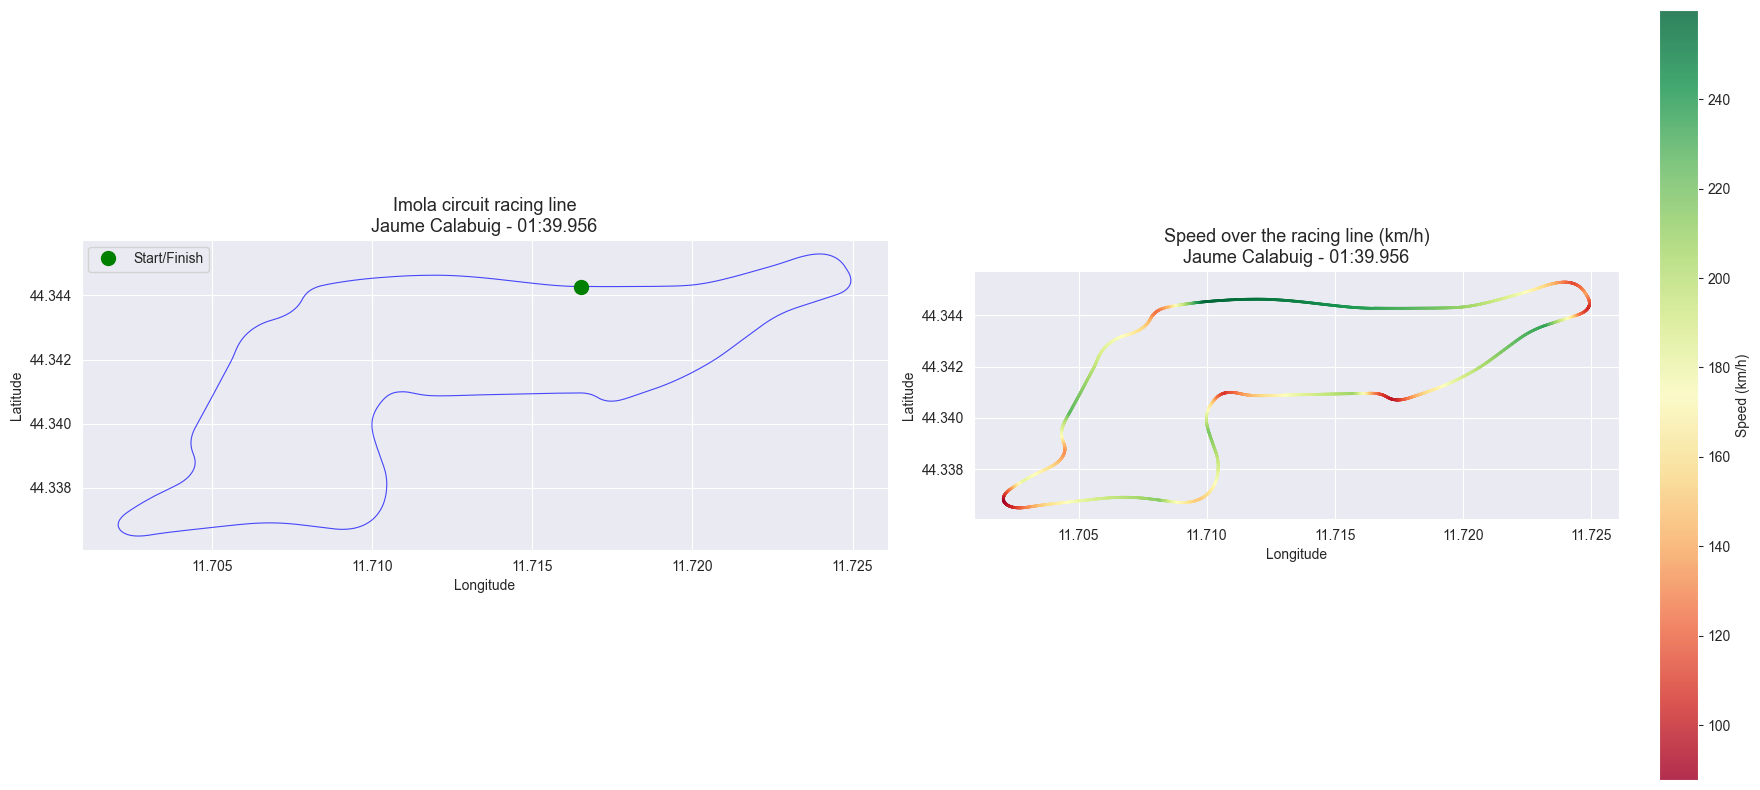

In [27]:
# Take the fastest lap for the reference map
fastest_idx = meta_df['lap_time_s'].idxmin()
fastest_driver = meta_df.loc[fastest_idx, 'driver']
fastest_time = meta_df.loc[fastest_idx, 'lap_time_str']

# Find the fastest lap in laps_data
fastest_lap = None
for lap in laps_data:
    if (lap['driver'].iloc[0] == fastest_driver and 
        abs(lap['lap_time_s'].iloc[0] - meta_df.loc[fastest_idx, 'lap_time_s']) < 0.001):
        fastest_lap = lap
        break

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Simple circuit map
axes[0].plot(fastest_lap['Lon'], fastest_lap['Lat'], 'b-', linewidth=0.8, alpha=0.7)
axes[0].set_title(f'Imola circuit racing line\n{fastest_driver} - {fastest_time}', fontsize=13)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_aspect('equal')
# Mark start/finish
axes[0].plot(fastest_lap['Lon'].iloc[0], fastest_lap['Lat'].iloc[0], 'go', markersize=10, label='Start/Finish')
axes[0].legend()

# Map colored by speed
#!! La velocidad esta a m/s, no a km/h --> Para convertir a km/h multiplicar por 3.6
speed_kmh = fastest_lap['Speed'] * 3.6  # Convert m/s to km/h
scatter = axes[1].scatter(fastest_lap['Lon'], fastest_lap['Lat'], 
                          c=speed_kmh, cmap='RdYlGn', s=1, alpha=0.8)
axes[1].set_title(f'Speed over the racing line (km/h)\n{fastest_driver} - {fastest_time}', fontsize=13)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_aspect('equal')
plt.colorbar(scatter, ax=axes[1], label='Speed (km/h)')



plt.tight_layout()
plt.show()

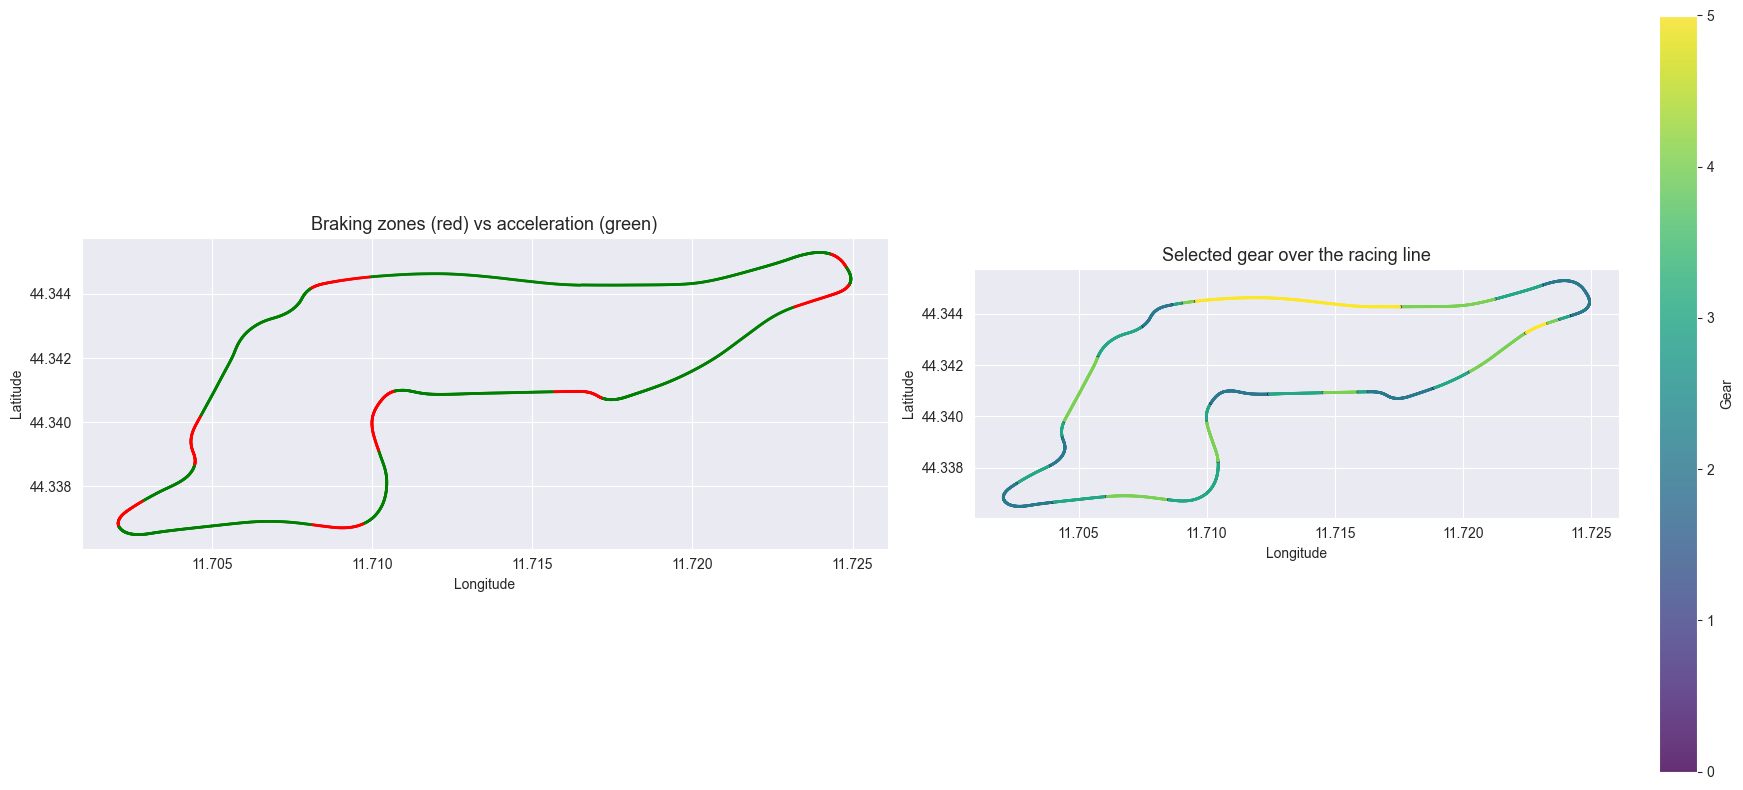

In [9]:
# Map with braking zones highlighted
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Colored by brake
brake_colors = ['green' if b == 0 else 'red' for b in fastest_lap['Brake']]
axes[0].scatter(fastest_lap['Lon'], fastest_lap['Lat'], c=brake_colors, s=1, alpha=0.6)
axes[0].set_title('Braking zones (red) vs acceleration (green)', fontsize=13)
axes[0].set_aspect('equal')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Colored by gear
scatter2 = axes[1].scatter(fastest_lap['Lon'], fastest_lap['Lat'],
                           c=fastest_lap['Gear'], cmap='viridis', s=1, alpha=0.8)
axes[1].set_title('Selected gear over the racing line', fontsize=13)
axes[1].set_aspect('equal')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
plt.colorbar(scatter2, ax=axes[1], label='Gear')

plt.tight_layout()
plt.show()

## 5. Lap time distribution

Understand how lap times are distributed and define what we consider a "fast lap" and a "slow lap".

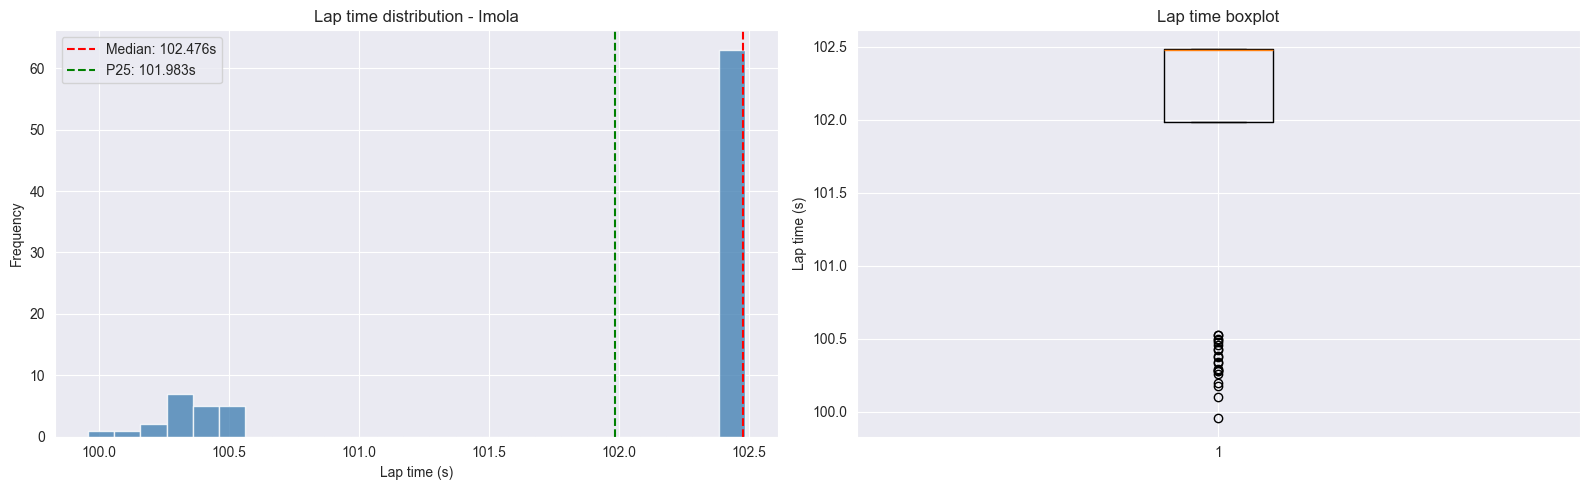


=== LAP CLASSIFICATION ===
Fast (P25):    <= 101.983s → 21 laps
Average:       101.983s - 102.481s → 47 laps
Slow (P75):    > 102.481s → 16 laps


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Lap time histogram
axes[0].hist(meta_df['lap_time_s'], bins=25, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(meta_df['lap_time_s'].median(), color='red', linestyle='--', label=f'Median: {meta_df["lap_time_s"].median():.3f}s')
axes[0].axvline(meta_df['lap_time_s'].quantile(0.25), color='green', linestyle='--', label=f'P25: {meta_df["lap_time_s"].quantile(0.25):.3f}s')
axes[0].set_xlabel('Lap time (s)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Lap time distribution - Imola')
axes[0].legend()

# Boxplot
axes[1].boxplot(meta_df['lap_time_s'], vert=True)
axes[1].set_ylabel('Lap time (s)')
axes[1].set_title('Lap time boxplot')

plt.tight_layout()
plt.show()

# Define performance groups
p25 = meta_df['lap_time_s'].quantile(0.25)
p75 = meta_df['lap_time_s'].quantile(0.75)
print(f'\n=== LAP CLASSIFICATION ===')
print(f'Fast (P25):    <= {p25:.3f}s → {(meta_df["lap_time_s"] <= p25).sum()} laps')
print(f'Average:       {p25:.3f}s - {p75:.3f}s → {((meta_df["lap_time_s"] > p25) & (meta_df["lap_time_s"] <= p75)).sum()} laps')
print(f'Slow (P75):    > {p75:.3f}s → {(meta_df["lap_time_s"] > p75).sum()} laps')

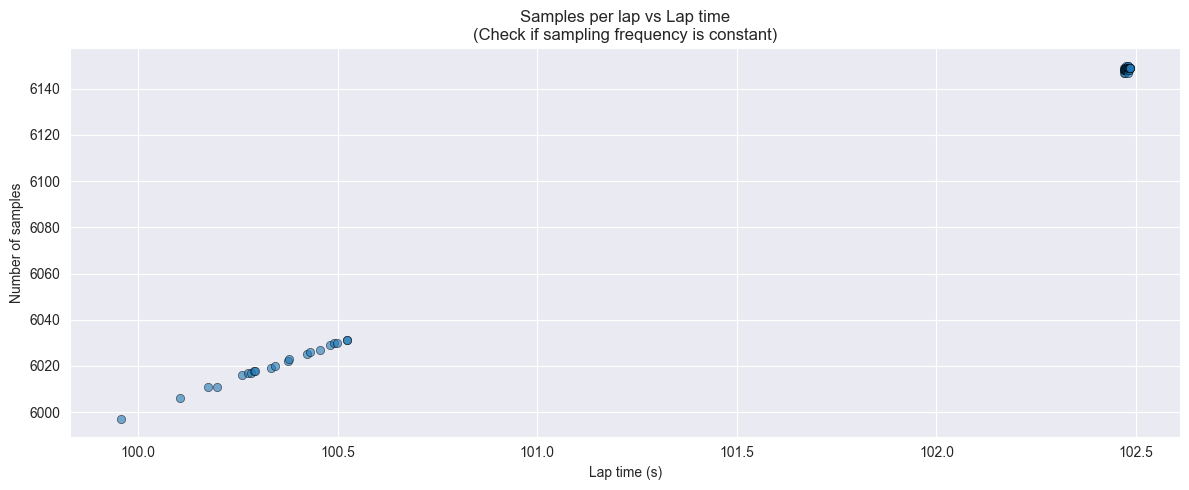

Samples vs time correlation: 1.0000


In [11]:
# Number of samples per lap vs lap time
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(meta_df['lap_time_s'], meta_df['n_samples'], alpha=0.6, edgecolors='black', linewidth=0.5)
ax.set_xlabel('Lap time (s)')
ax.set_ylabel('Number of samples')
ax.set_title('Samples per lap vs Lap time\n(Check if sampling frequency is constant)')
plt.tight_layout()
plt.show()

print(f'Samples vs time correlation: {meta_df["n_samples"].corr(meta_df["lap_time_s"]):.4f}')

## 6. Analysis of each telemetry channel

For each channel, visualize its profile along the lap (vs LapDistPct) and its distribution.

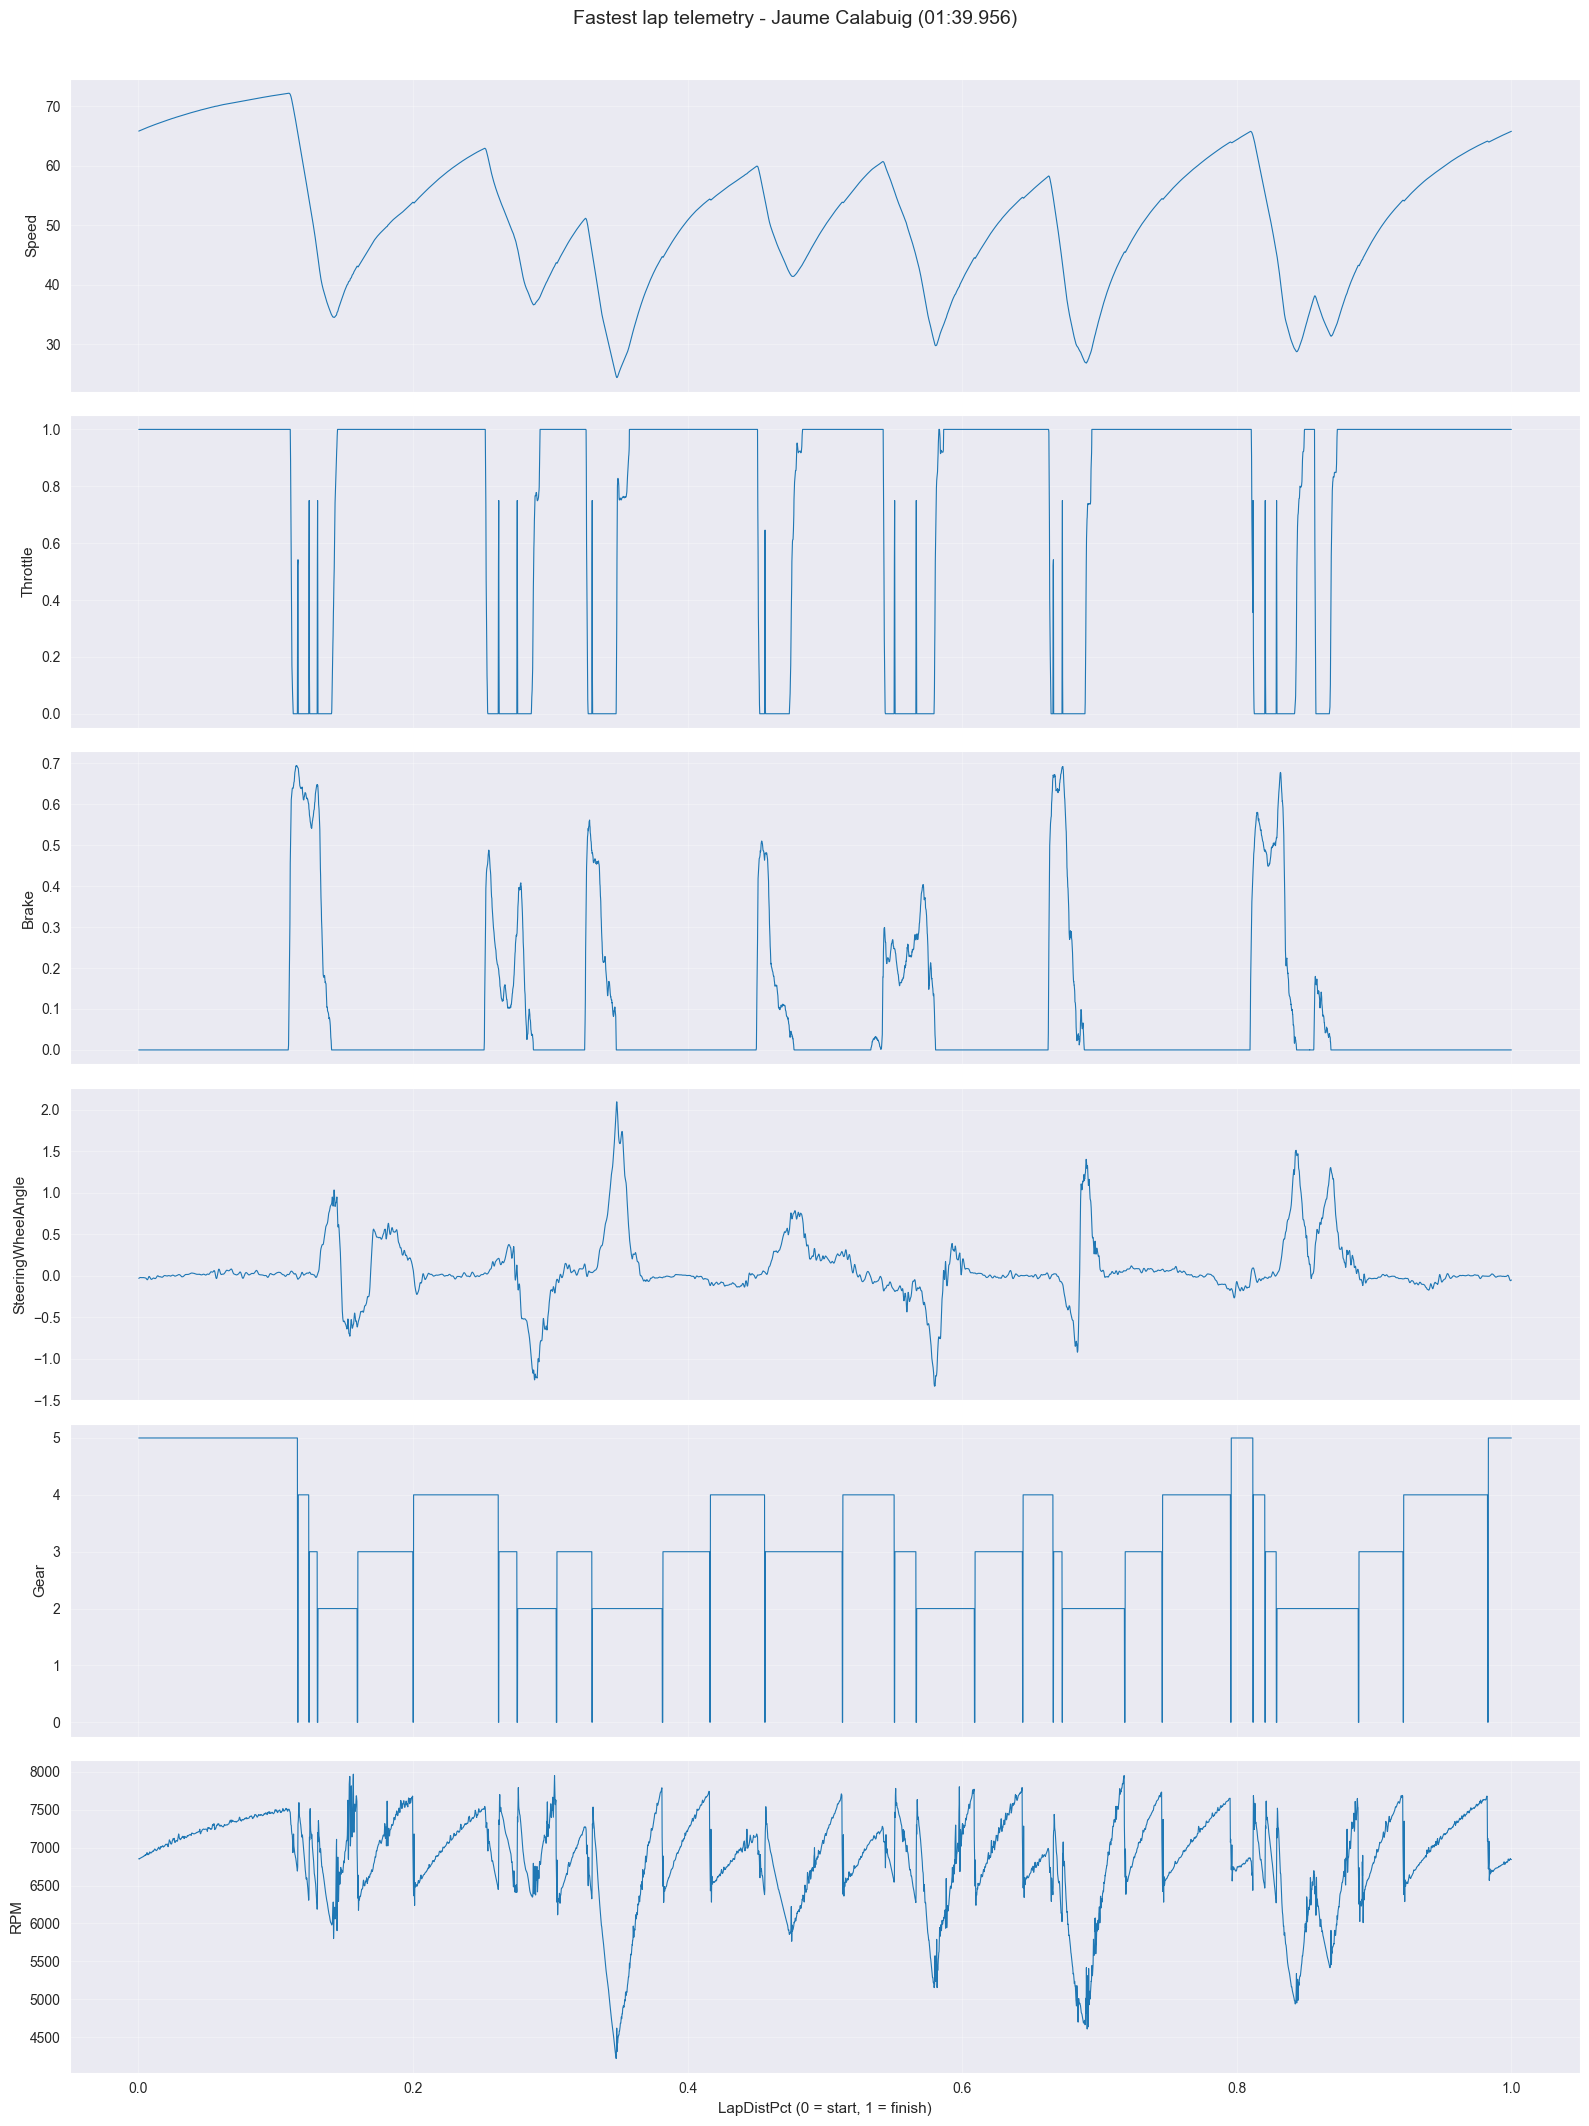

In [12]:
# Full telemetry of the fastest lap
channels = ['Speed', 'Throttle', 'Brake', 'SteeringWheelAngle', 'Gear', 'RPM']

fig, axes = plt.subplots(len(channels), 1, figsize=(16, 3.5 * len(channels)), sharex=True)

for i, ch in enumerate(channels):
    axes[i].plot(fastest_lap['LapDistPct'], fastest_lap[ch], linewidth=0.8)
    axes[i].set_ylabel(ch, fontsize=11)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('LapDistPct (0 = start, 1 = finish)', fontsize=11)
fig.suptitle(f'Fastest lap telemetry - {fastest_driver} ({fastest_time})', 
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

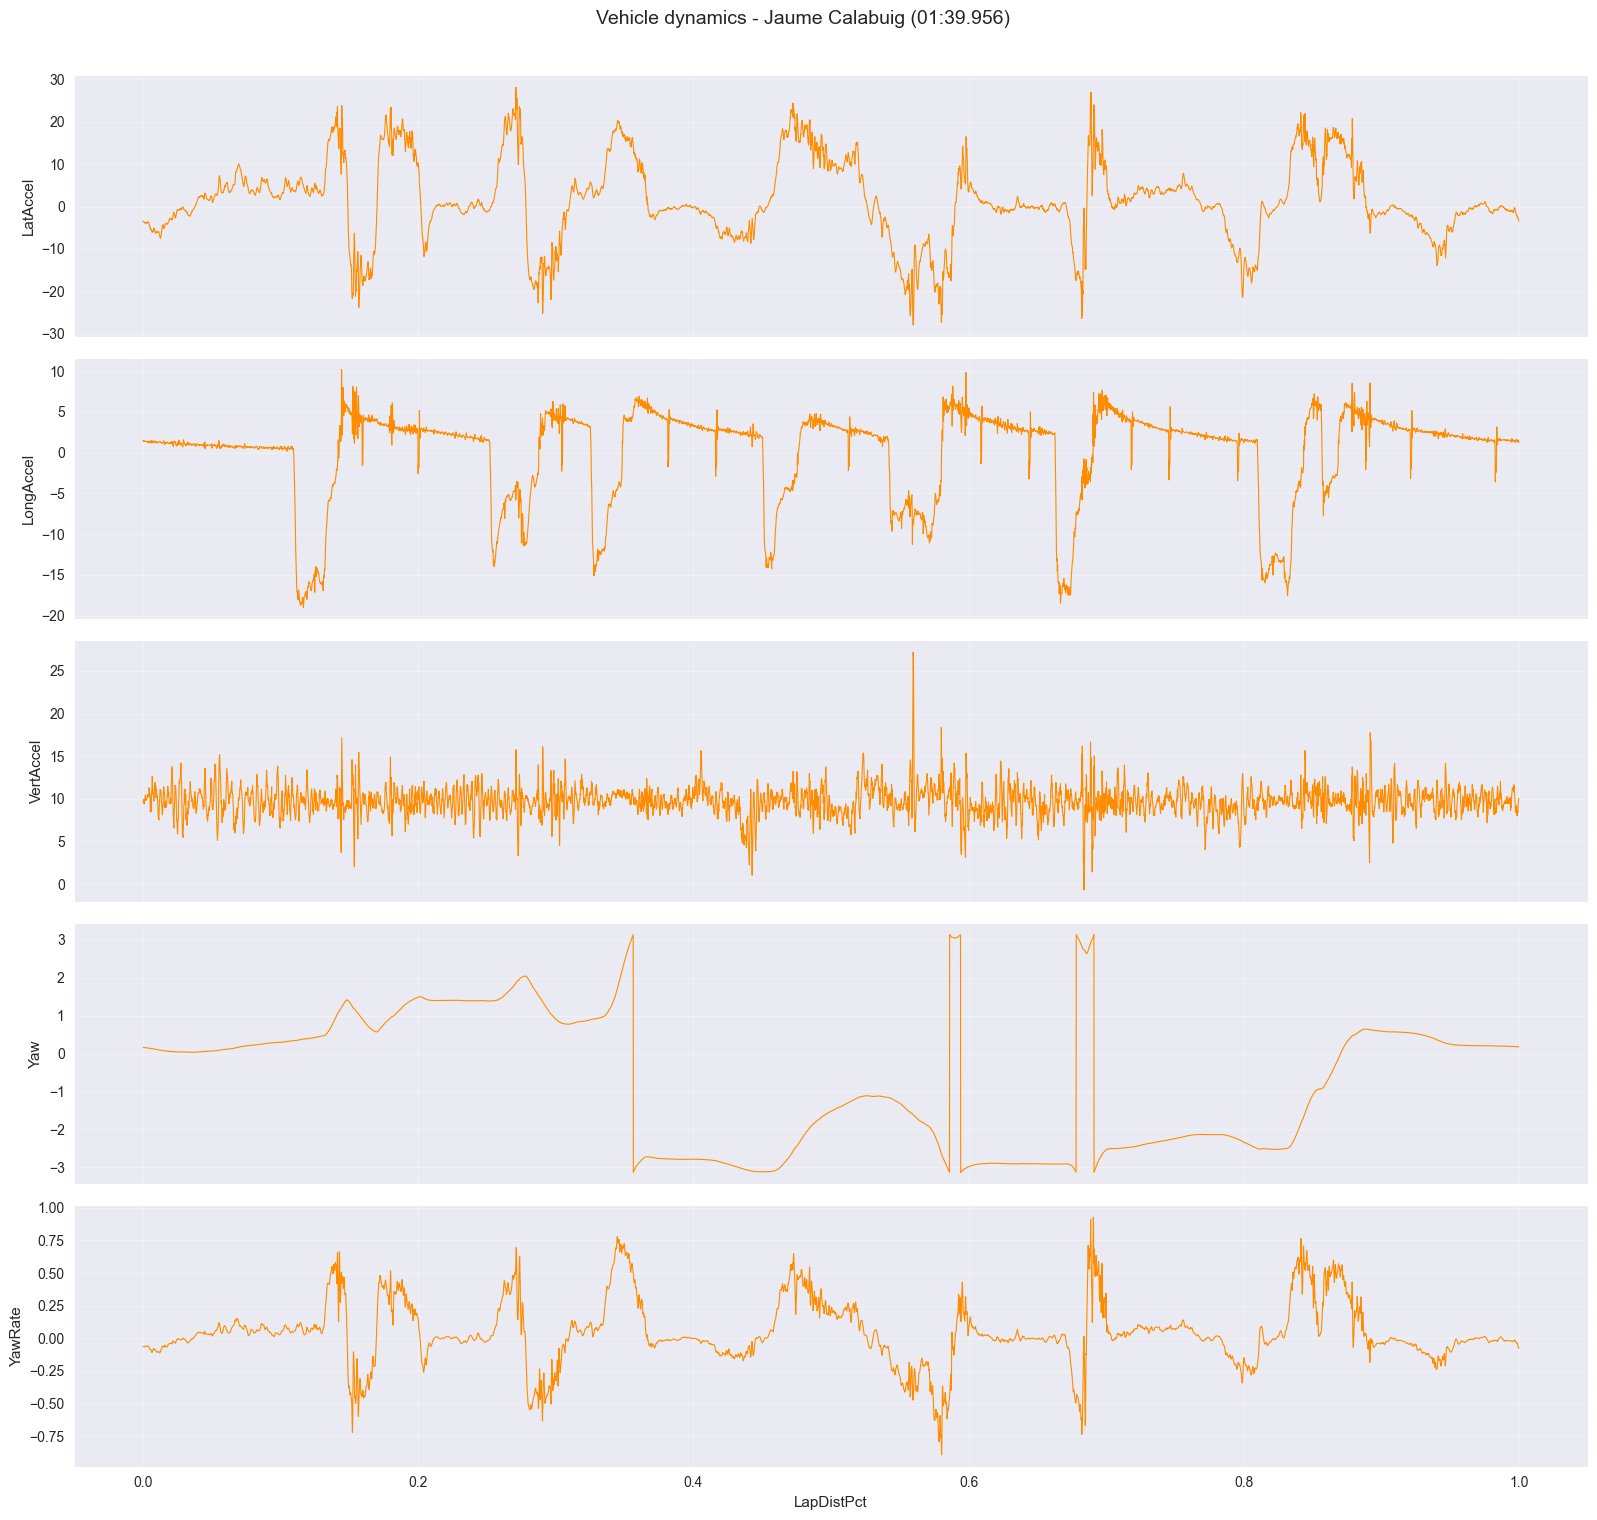

In [ ]:
# Vehicle dynamics and accelerations
dyn_channels = ['LatAccel', 'LongAccel', 'VertAccel', 'Yaw', 'YawRate']

fig, axes = plt.subplots(len(dyn_channels), 1, figsize=(16, 3 * len(dyn_channels)), sharex=True)

for i, ch in enumerate(dyn_channels):
    axes[i].plot(fastest_lap['LapDistPct'], fastest_lap[ch], linewidth=0.8, color='darkorange')
    axes[i].set_ylabel(ch, fontsize=11)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('LapDistPct', fontsize=11)
fig.suptitle(f'Vehicle dynamics - {fastest_driver} ({fastest_time})', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


"""
LatAccel: indica la fuerza G lateral que experimenta el coche. Valores positivos indican fuerzas hacia la derecha, negativos hacia la izquierda. 
Las grandes oscilaciones suelen indicar zonas de curvas rápidas o cambios bruscos de dirección.
LongAccel: las grandes caidas negativas son zonas de frenada fuerte, las grandes positivas son zonas de aceleración lateral (curvas rápidas).
VertAccel: indica la fuerza G vertical. Picos positivos pueden indicar baches o zonas de alta carga aerodinámica, picos negativos pueden indicar zonas de baja carga o saltos.
Yaw & YawRate: indican la orientación del coche y su velocidad de cambio. Picos en YawRate suelen coincidir con cambios de dirección (curvas).
"""

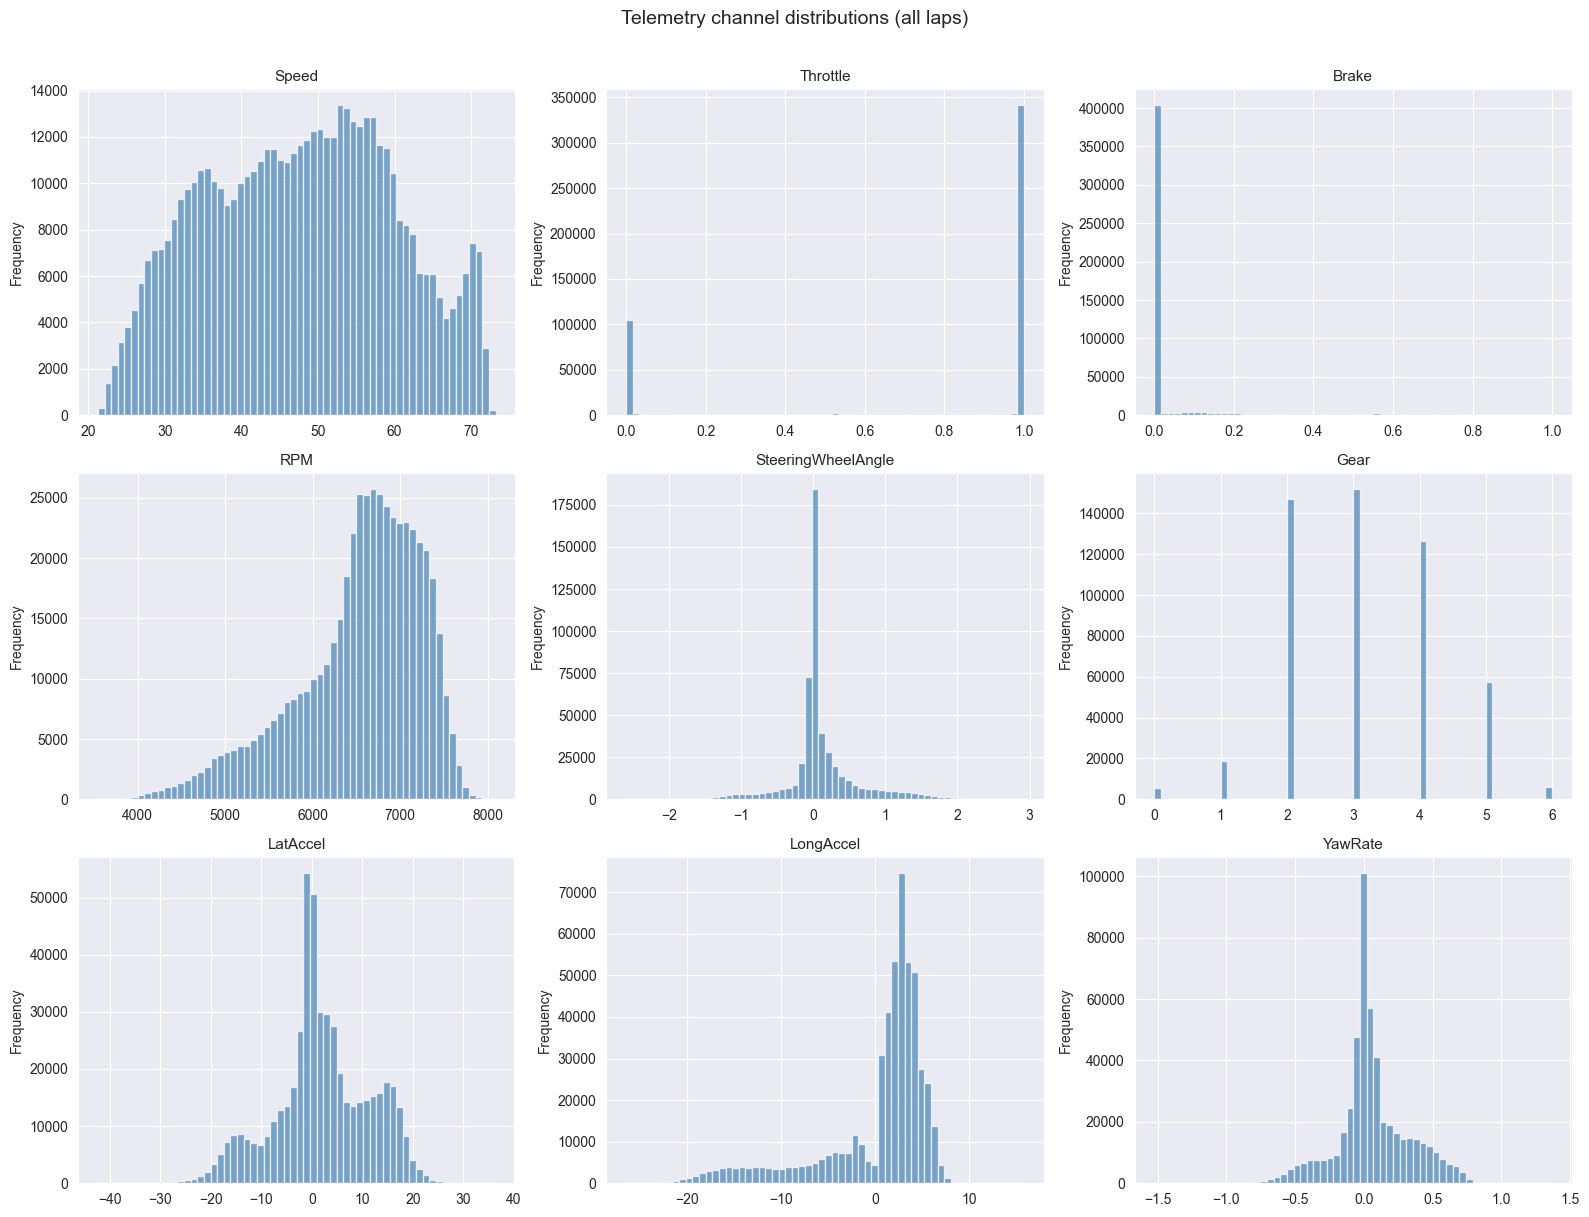

In [ ]:
# Distributions of main channels (all laps)
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

plot_cols = ['Speed', 'Throttle', 'Brake', 'RPM', 'SteeringWheelAngle', 
             'Gear', 'LatAccel', 'LongAccel', 'YawRate']

for i, col in enumerate(plot_cols):
    axes[i].hist(all_laps[col], bins=60, alpha=0.7, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Frequency')

fig.suptitle('Telemetry channel distributions (all laps)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

"""
Speed: indica la velocidad del coche en km/h.
Throttle: indica el porcentaje de apertura del acelerador.
Brake: indica el porcentaje de aplicación del freno.
RPM: indica las revoluciones por minuto del motor.
SteeringWheelAngle: indica el ángulo del volante.
Gear: indica la marcha seleccionada.
LatAccel: indica la fuerza G lateral que experimenta el coche.
LongAccel: indica la aceleración longitudinal del coche.
YawRate: indica la velocidad de cambio de orientación del coche.
"""

## 7. Interpolation to a uniform LapDistPct grid

**Problem:** Each lap has a different number of samples and the `LapDistPct` values don't match exactly between laps.

**Solution:** Interpolate each lap to a uniform grid (e.g., 1000 equally spaced points from 0 to 1) to enable lap-to-lap comparison.

In [15]:
# Define uniform grid
N_POINTS = 1000  # Points per lap after interpolation
uniform_dist = np.linspace(0, 1, N_POINTS)

# Channels to interpolate (only continuous numeric)
INTERP_COLS = ['Speed', 'Throttle', 'Brake', 'RPM', 'SteeringWheelAngle',
               'Gear', 'LatAccel', 'LongAccel', 'VertAccel', 'Yaw', 'YawRate',
               'Lat', 'Lon']

def interpolate_lap(lap_df, target_dist, cols):
    """Interpolate a lap to a uniform LapDistPct grid."""
    result = {}
    x = lap_df['LapDistPct'].values
    
    # Ensure x is monotonically increasing (some data may have duplicates)
    # Remove duplicates in x keeping the last value
    mask = np.diff(x, prepend=-1) > 0
    x_clean = x[mask]
    
    for col in cols:
        y = lap_df[col].values
        y_clean = y[mask]
        
        try:
            f = interp1d(x_clean, y_clean, kind='linear', fill_value='extrapolate')
            result[col] = f(target_dist)
        except Exception as e:
            result[col] = np.full(len(target_dist), np.nan)
    
    result['LapDistPct'] = target_dist
    return pd.DataFrame(result)

# Interpolate all laps
laps_interpolated = []
for i, lap in enumerate(laps_data):
    interp = interpolate_lap(lap, uniform_dist, INTERP_COLS)
    interp['driver'] = lap['driver'].iloc[0]
    interp['lap_time_s'] = lap['lap_time_s'].iloc[0]
    interp['lap_idx'] = i
    laps_interpolated.append(interp)

print(f'Interpolated laps: {len(laps_interpolated)}')
print(f'Shape of each interpolated lap: {laps_interpolated[0].shape}')
print(f'\nExample (first rows of the first interpolated lap):')
laps_interpolated[0].head()

Interpolated laps: 84
Shape of each interpolated lap: (1000, 17)

Example (first rows of the first interpolated lap):


,Speed,Throttle,Brake,RPM,SteeringWheelAngle,Gear,LatAccel,LongAccel,VertAccel,Yaw,YawRate,Lat,Lon,LapDistPct,driver,lap_time_s,lap_idx
0,65.616441,1.0,0.0,6825.701668,-0.147764,5.0,-3.819859,1.232631,7.338002,0.120087,-0.105124,44.344254,11.716524,0.000000,Alden Lisboa,102.473,0
1,65.714223,1.0,0.0,6836.393584,-0.073197,5.0,-6.718720,1.324473,8.682704,0.109769,-0.141442,44.344257,11.716463,0.001001,Alden Lisboa,102.473,0
2,65.809546,1.0,0.0,6852.369120,-0.059123,5.0,-7.537065,1.418419,9.681882,0.100255,-0.120328,44.344261,11.716402,0.002002,Alden Lisboa,102.473,0
3,65.906286,1.0,0.0,6852.460762,-0.040421,5.0,-6.974273,1.371228,9.582018,0.091985,-0.100722,44.344265,11.716342,0.003003,Alden Lisboa,102.473,0
4,66.003637,1.0,0.0,6859.515067,-0.002810,5.0,-6.010956,1.396822,11.154394,0.085880,-0.069048,44.344269,11.716281,0.004004,Alden Lisboa,102.473,0


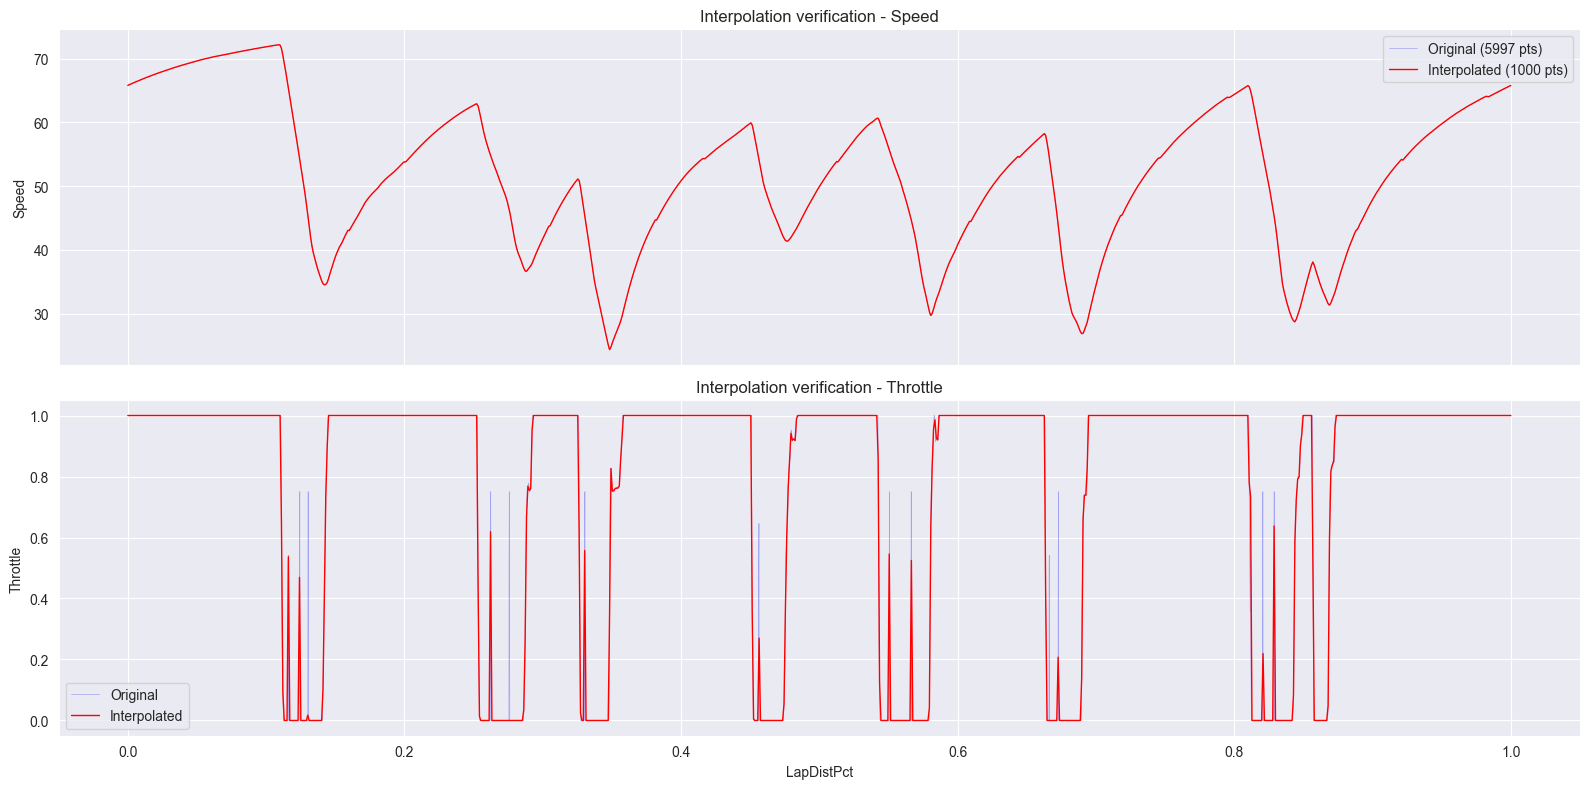

In [ ]:
# Verify interpolation: compare original vs interpolated for the fastest lap
# Find the index of the fastest lap in laps_interpolated
fastest_interp = None
for lip in laps_interpolated:
    if (lip['driver'].iloc[0] == fastest_driver and 
        abs(lip['lap_time_s'].iloc[0] - meta_df.loc[fastest_idx, 'lap_time_s']) < 0.001):
        fastest_interp = lip
        break

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Speed: original vs interpolated
axes[0].plot(fastest_lap['LapDistPct'], fastest_lap['Speed'], 'b-', alpha=0.3, linewidth=0.5, label=f'Original ({len(fastest_lap)} pts)')
axes[0].plot(fastest_interp['LapDistPct'], fastest_interp['Speed'], 'r-', linewidth=1, label=f'Interpolated ({N_POINTS} pts)')
axes[0].set_ylabel('Speed')
axes[0].set_title('Interpolation verification - Speed')
axes[0].legend()

# Throttle: original vs interpolated
axes[1].plot(fastest_lap['LapDistPct'], fastest_lap['Throttle'], 'b-', alpha=0.3, linewidth=0.5, label='Original')
axes[1].plot(fastest_interp['LapDistPct'], fastest_interp['Throttle'], 'r-', linewidth=1, label='Interpolated')
axes[1].set_ylabel('Throttle')
axes[1].set_xlabel('LapDistPct')
axes[1].set_title('Interpolation verification - Throttle')
axes[1].legend()

plt.tight_layout()
plt.show()

""" 
Ver que la interpolación mantiene la forma general de las curvas originales, pero con un número fijo de puntos (1000) para facilitar comparaciones entre laps.
En throttle podemos ver como hay zonas de acelerador o frenada que perdemos detalles de la original (al reducir la resolucion de 6000 a 1000 puntos), 
pero la forma general se mantiene
"""

## 8. Comparison: fast laps vs slow laps

Overlay telemetry channels from fast laps (top 25%) vs slow laps (bottom 25%) to identify where performance differences originate.

In [17]:
# Build the 3D telemetry matrix: (n_laps, N_POINTS, n_features)
feature_cols = ['Speed', 'Throttle', 'Brake', 'RPM', 'SteeringWheelAngle',
                'Gear', 'LatAccel', 'LongAccel', 'YawRate']

# Build the matrix
telemetry_matrix = np.zeros((len(laps_interpolated), N_POINTS, len(feature_cols)))
lap_times = np.zeros(len(laps_interpolated))

for i, lip in enumerate(laps_interpolated):
    for j, col in enumerate(feature_cols):
        telemetry_matrix[i, :, j] = lip[col].values
    lap_times[i] = lip['lap_time_s'].iloc[0]

print(f'Telemetry matrix: {telemetry_matrix.shape}')
print(f'  → {telemetry_matrix.shape[0]} laps × {telemetry_matrix.shape[1]} points × {telemetry_matrix.shape[2]} features')

# Separate fast and slow laps
p25_thresh = np.percentile(lap_times, 25)
p75_thresh = np.percentile(lap_times, 75)

fast_mask = lap_times <= p25_thresh
slow_mask = lap_times >= p75_thresh

fast_matrix = telemetry_matrix[fast_mask]
slow_matrix = telemetry_matrix[slow_mask]

print(f'\nFast laps (≤ {p25_thresh:.3f}s): {fast_matrix.shape[0]}')
print(f'Slow laps (≥ {p75_thresh:.3f}s): {slow_matrix.shape[0]}')

Telemetry matrix: (84, 1000, 9)
  → 84 laps × 1000 points × 9 features

Fast laps (≤ 101.983s): 21
Slow laps (≥ 102.481s): 23


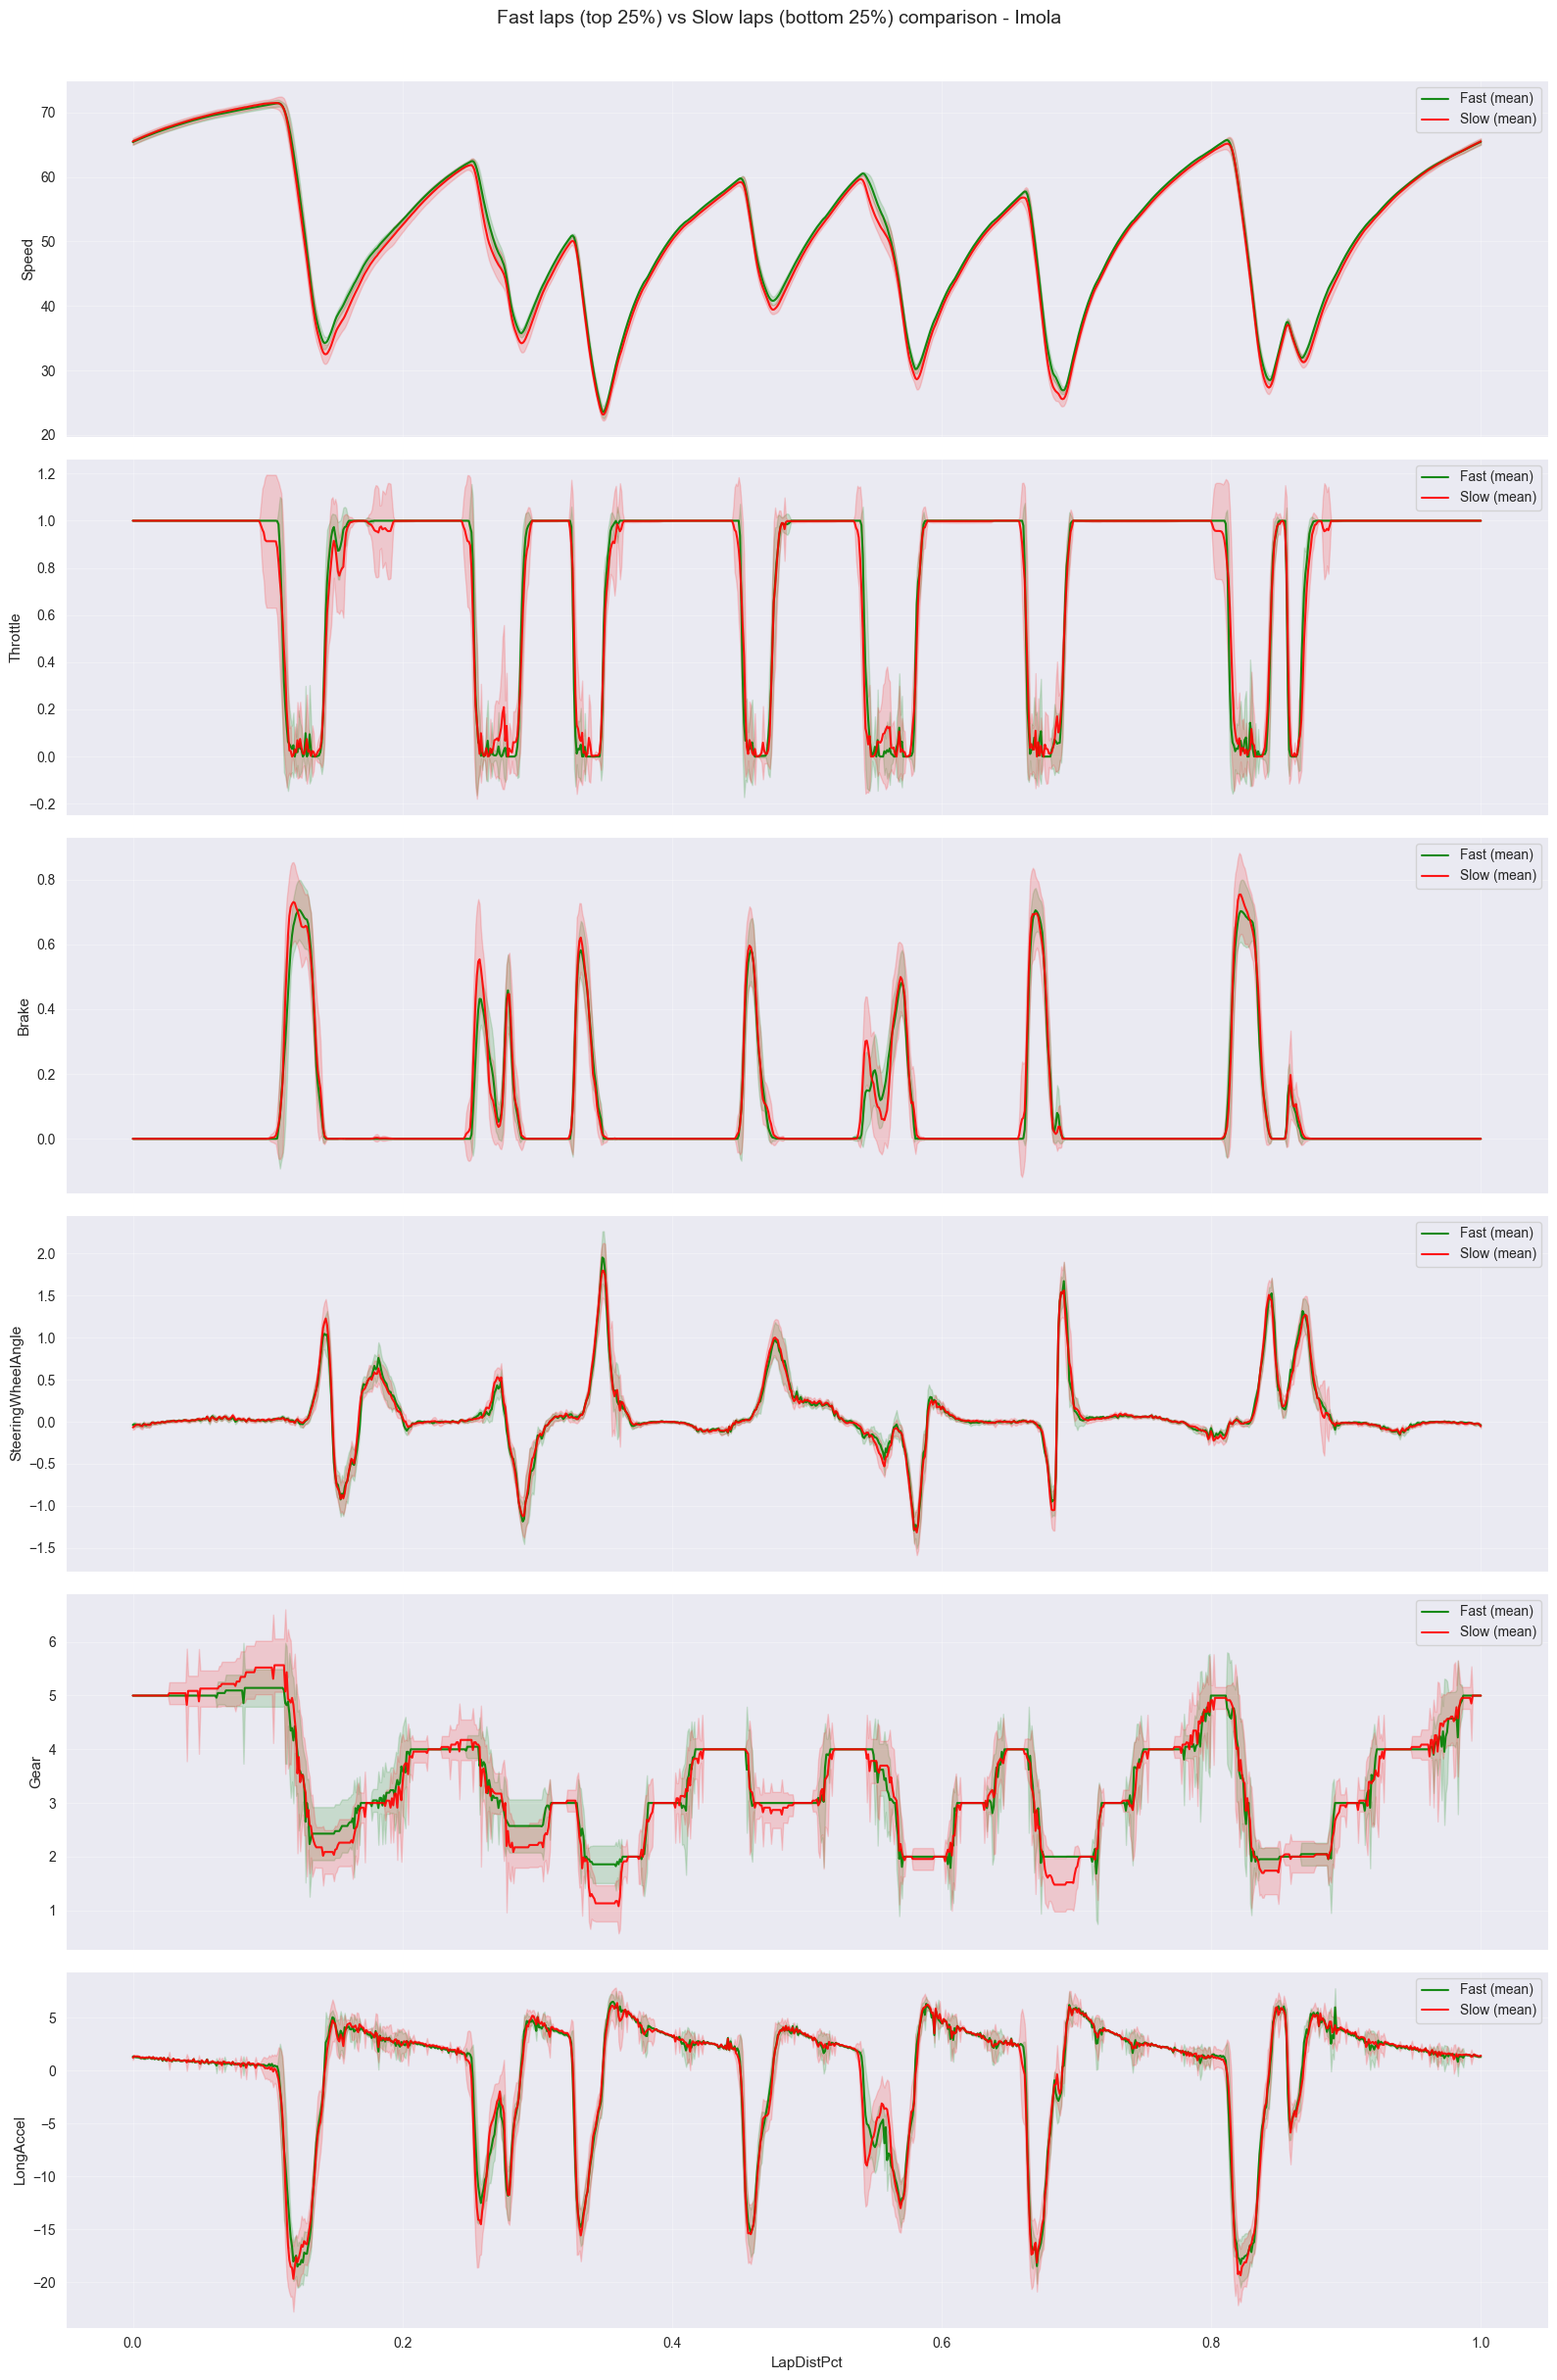

In [18]:
# Visual comparison: mean and standard deviation of fast vs slow laps
compare_channels = ['Speed', 'Throttle', 'Brake', 'SteeringWheelAngle', 'Gear', 'LongAccel']

fig, axes = plt.subplots(len(compare_channels), 1, figsize=(16, 4 * len(compare_channels)), sharex=True)

for i, ch in enumerate(compare_channels):
    ch_idx = feature_cols.index(ch)
    
    # Mean and std of fast laps
    fast_mean = fast_matrix[:, :, ch_idx].mean(axis=0)
    fast_std = fast_matrix[:, :, ch_idx].std(axis=0)
    
    # Mean and std of slow laps
    slow_mean = slow_matrix[:, :, ch_idx].mean(axis=0)
    slow_std = slow_matrix[:, :, ch_idx].std(axis=0)
    
    axes[i].plot(uniform_dist, fast_mean, 'g-', linewidth=1.5, label='Fast (mean)', alpha=0.9)
    axes[i].fill_between(uniform_dist, fast_mean - fast_std, fast_mean + fast_std, alpha=0.15, color='green')
    
    axes[i].plot(uniform_dist, slow_mean, 'r-', linewidth=1.5, label='Slow (mean)', alpha=0.9)
    axes[i].fill_between(uniform_dist, slow_mean - slow_std, slow_mean + slow_std, alpha=0.15, color='red')
    
    axes[i].set_ylabel(ch, fontsize=11)
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('LapDistPct', fontsize=11)
fig.suptitle('Fast laps (top 25%) vs Slow laps (bottom 25%) comparison - Imola', 
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

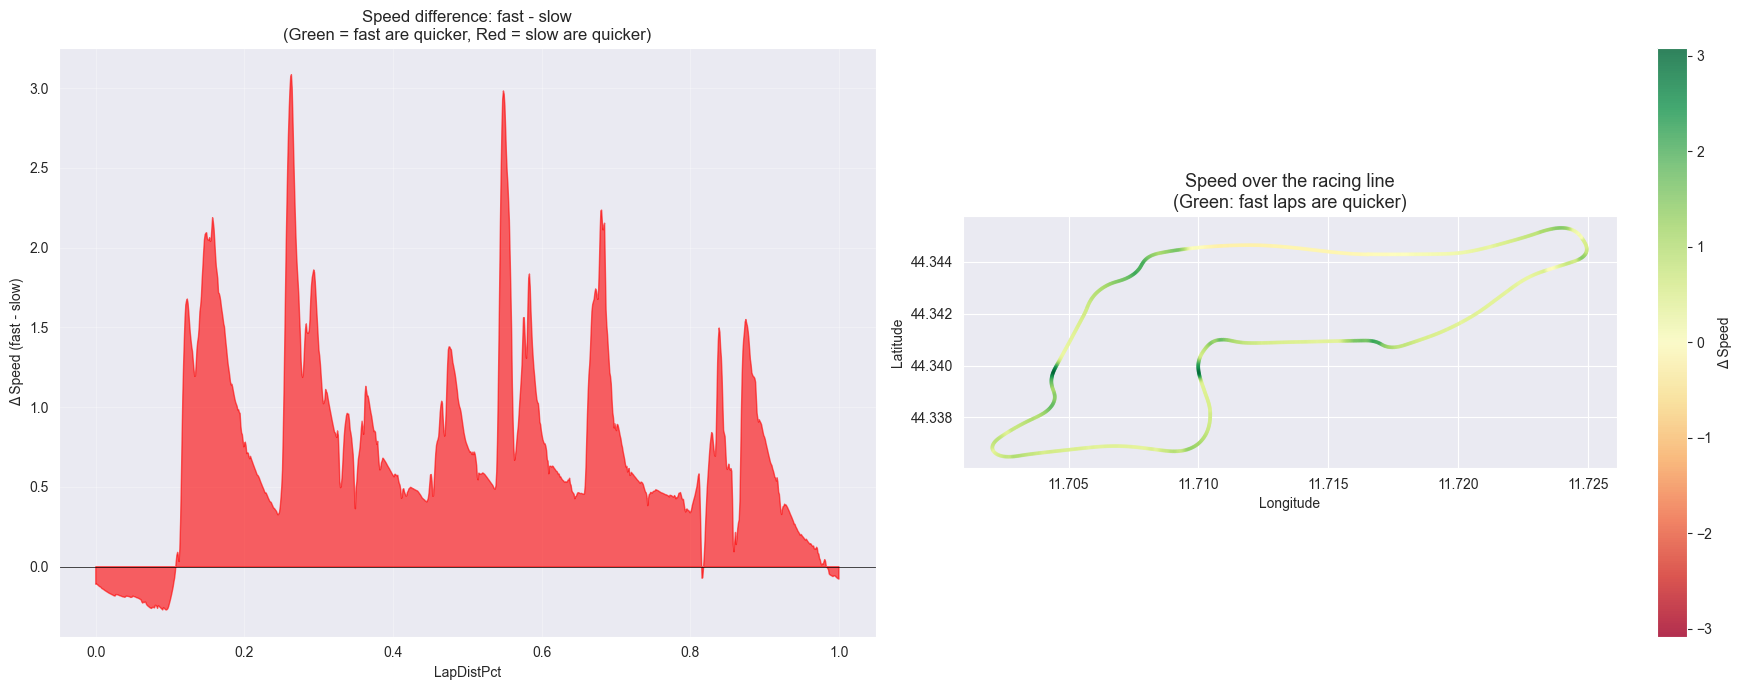

In [19]:
# Absolute speed difference between fast and slow laps by circuit zone
speed_idx = feature_cols.index('Speed')
speed_diff = fast_matrix[:, :, speed_idx].mean(axis=0) - slow_matrix[:, :, speed_idx].mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Line chart of the difference
axes[0].fill_between(uniform_dist, speed_diff, alpha=0.6, 
                     color=['green' if d > 0 else 'red' for d in speed_diff])
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].set_xlabel('LapDistPct')
axes[0].set_ylabel('Δ Speed (fast - slow)')
axes[0].set_title('Speed difference: fast - slow\n(Green = fast are quicker, Red = slow are quicker)')
axes[0].grid(True, alpha=0.3)

# Heatmap over the circuit - where time is gained/lost
# Use coordinates from the fastest interpolated lap
scatter = axes[1].scatter(fastest_interp['Lon'], fastest_interp['Lat'],
                          c=speed_diff, cmap='RdYlGn', s=3, alpha=0.8,
                          vmin=-np.abs(speed_diff).max(), vmax=np.abs(speed_diff).max())
axes[1].set_title('Speed over the racing line\n(Green: fast laps are quicker)', fontsize=13)
axes[1].set_aspect('equal')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
plt.colorbar(scatter, ax=axes[1], label='Δ Speed')

plt.tight_layout()
plt.show()

## 9. Channel correlation

Understand which channels are correlated (to avoid redundancy) and which provide independent information.

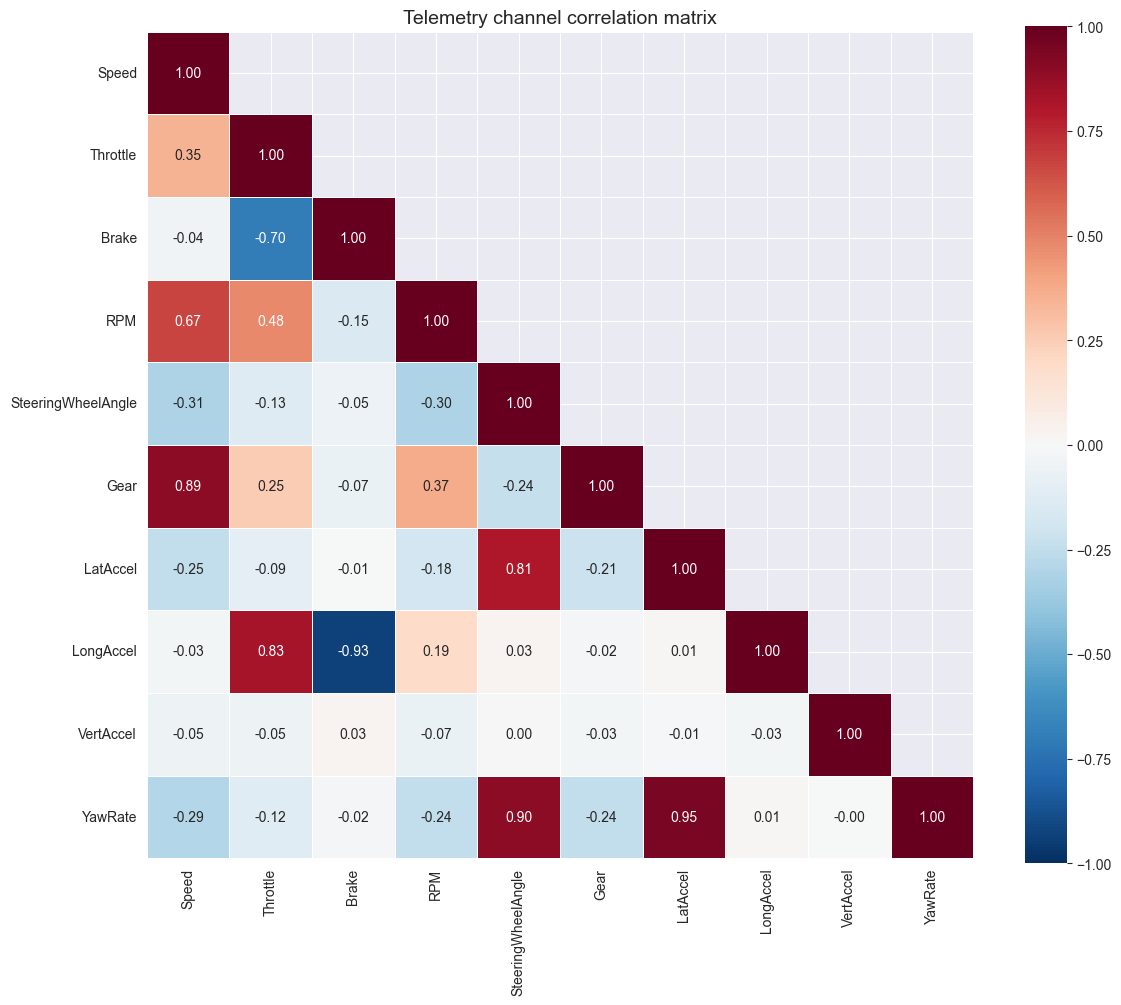

=== STRONGEST CORRELATIONS (|r| > 0.5) ===
  Speed                     ↔ RPM                      : r = 0.672
  Speed                     ↔ Gear                     : r = 0.891
  Throttle                  ↔ Brake                    : r = -0.696
  Throttle                  ↔ LongAccel                : r = 0.830
  Brake                     ↔ LongAccel                : r = -0.933
  SteeringWheelAngle        ↔ LatAccel                 : r = 0.808
  SteeringWheelAngle        ↔ YawRate                  : r = 0.897
  LatAccel                  ↔ YawRate                  : r = 0.946


In [20]:
# Correlation matrix of all numeric channels
corr_cols = ['Speed', 'Throttle', 'Brake', 'RPM', 'SteeringWheelAngle', 
             'Gear', 'LatAccel', 'LongAccel', 'VertAccel', 'YawRate']

corr_matrix = all_laps[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, ax=ax, vmin=-1, vmax=1,
            linewidths=0.5)
ax.set_title('Telemetry channel correlation matrix', fontsize=14)
plt.tight_layout()
plt.show()

# Strongest correlations
print('=== STRONGEST CORRELATIONS (|r| > 0.5) ===')
for i in range(len(corr_cols)):
    for j in range(i+1, len(corr_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            print(f'  {corr_cols[i]:25s} ↔ {corr_cols[j]:25s}: r = {r:.3f}')

## 10. Circuit segmentation into zones

Divide the lap into sectors based on speed and braking to identify key circuit zones: straights, braking zones, corners.

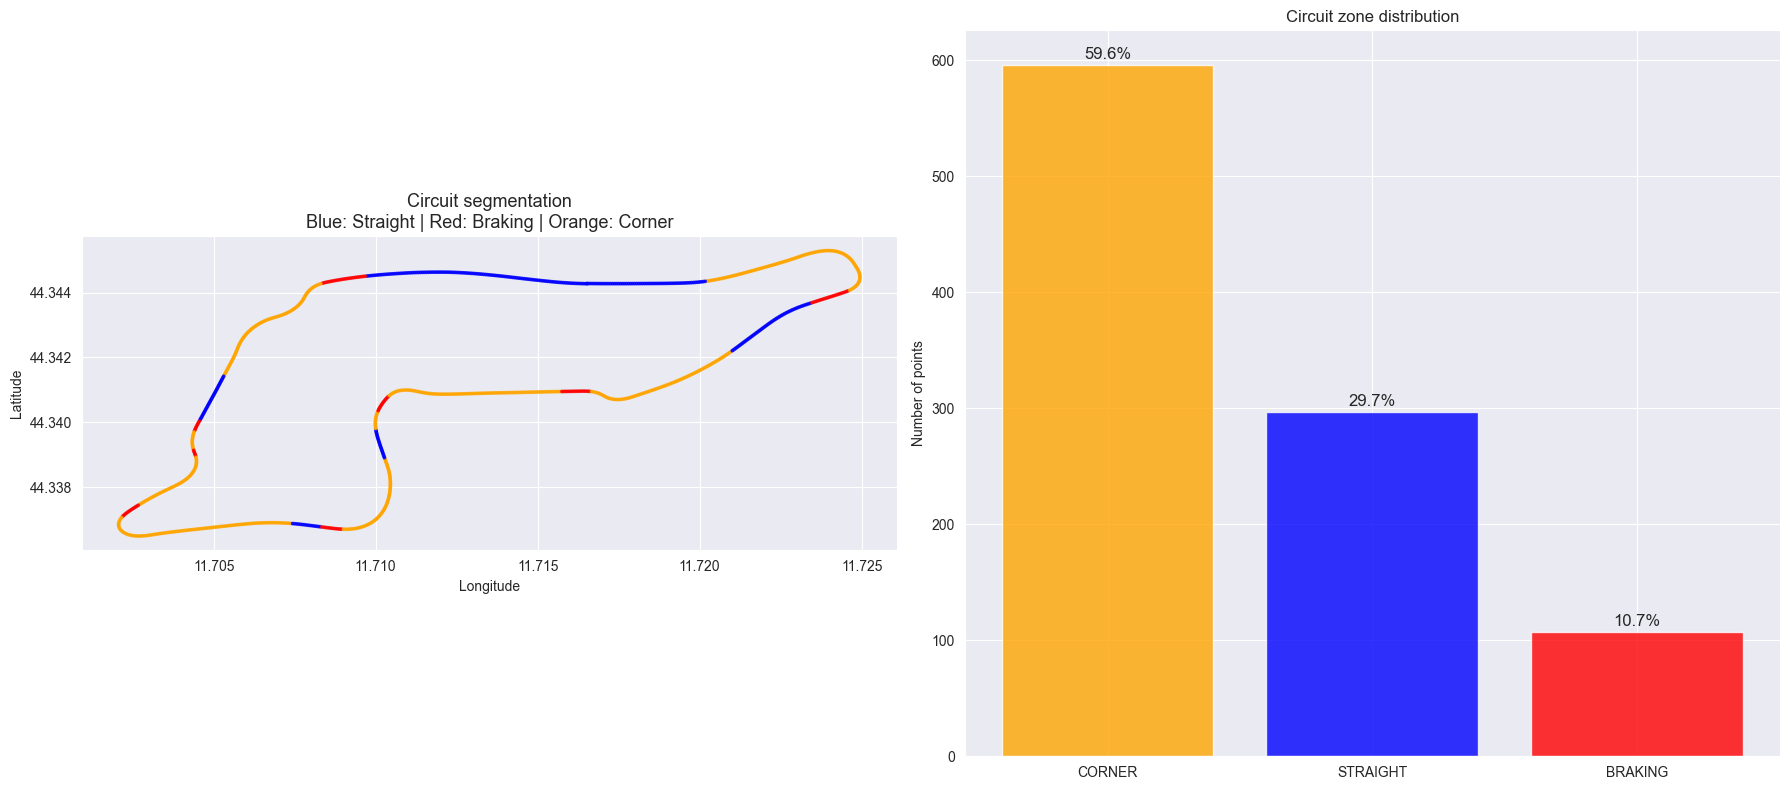

In [21]:
# Classify each point of the circuit as: STRAIGHT, BRAKING, CORNER
# Using the mean of fast laps as reference
speed_ref = fast_matrix[:, :, feature_cols.index('Speed')].mean(axis=0)
brake_ref = fast_matrix[:, :, feature_cols.index('Brake')].mean(axis=0)
throttle_ref = fast_matrix[:, :, feature_cols.index('Throttle')].mean(axis=0)
lat_accel_ref = fast_matrix[:, :, feature_cols.index('LatAccel')].mean(axis=0)

# Simple classification criteria
speed_median = np.median(speed_ref)
zones = []
for k in range(N_POINTS):
    if brake_ref[k] > 0.3:  # Significant braking
        zones.append('BRAKING')
    elif speed_ref[k] > speed_median * 1.1:  # High speed → straight
        zones.append('STRAIGHT')
    else:
        zones.append('CORNER')

zones = np.array(zones)

# Visualize the zones on the circuit
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

zone_colors = {'STRAIGHT': 'blue', 'BRAKING': 'red', 'CORNER': 'orange'}
colors = [zone_colors[z] for z in zones]

axes[0].scatter(fastest_interp['Lon'], fastest_interp['Lat'], c=colors, s=3, alpha=0.8)
axes[0].set_title('Circuit segmentation\nBlue: Straight | Red: Braking | Orange: Corner', fontsize=13)
axes[0].set_aspect('equal')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Zone distribution
zone_counts = pd.Series(zones).value_counts()
axes[1].bar(zone_counts.index, zone_counts.values, 
            color=[zone_colors[z] for z in zone_counts.index], alpha=0.8)
axes[1].set_title('Circuit zone distribution')
axes[1].set_ylabel('Number of points')
for i, (zone, count) in enumerate(zone_counts.items()):
    axes[1].text(i, count + 5, f'{count/N_POINTS*100:.1f}%', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

In [22]:
# Analyze where the most tenths are lost: difference by zone
speed_diff_abs = np.abs(speed_diff)

print('=== AVERAGE SPEED LOSS BY ZONE ===')
for zone in ['STRAIGHT', 'BRAKING', 'CORNER']:
    zone_mask = zones == zone
    avg_diff = speed_diff[zone_mask].mean()
    max_diff = speed_diff[zone_mask].max()
    min_diff = speed_diff[zone_mask].min()
    print(f'\n{zone}:')
    print(f'  Avg Speed:  {avg_diff:+.2f} m/s')
    print(f'  Max Speed:  {max_diff:+.2f} m/s')
    print(f'  Min Speed:  {min_diff:+.2f} m/s')
    print(f'  Affected points: {zone_mask.sum()}')

=== AVERAGE SPEED LOSS BY ZONE ===

STRAIGHT:
  Avg Speed:  +0.19 m/s
  Max Speed:  +2.98 m/s
  Min Speed:  -0.27 m/s
  Affected points: 297

BRAKING:
  Avg Speed:  +1.09 m/s
  Max Speed:  +3.07 m/s
  Min Speed:  -0.07 m/s
  Affected points: 107

CORNER:
  Avg Speed:  +0.95 m/s
  Max Speed:  +3.08 m/s
  Min Speed:  +0.09 m/s
  Affected points: 596


## 11. Lap-to-lap consistency

Evaluate intra-lap and inter-lap variability to understand how consistent the data is.

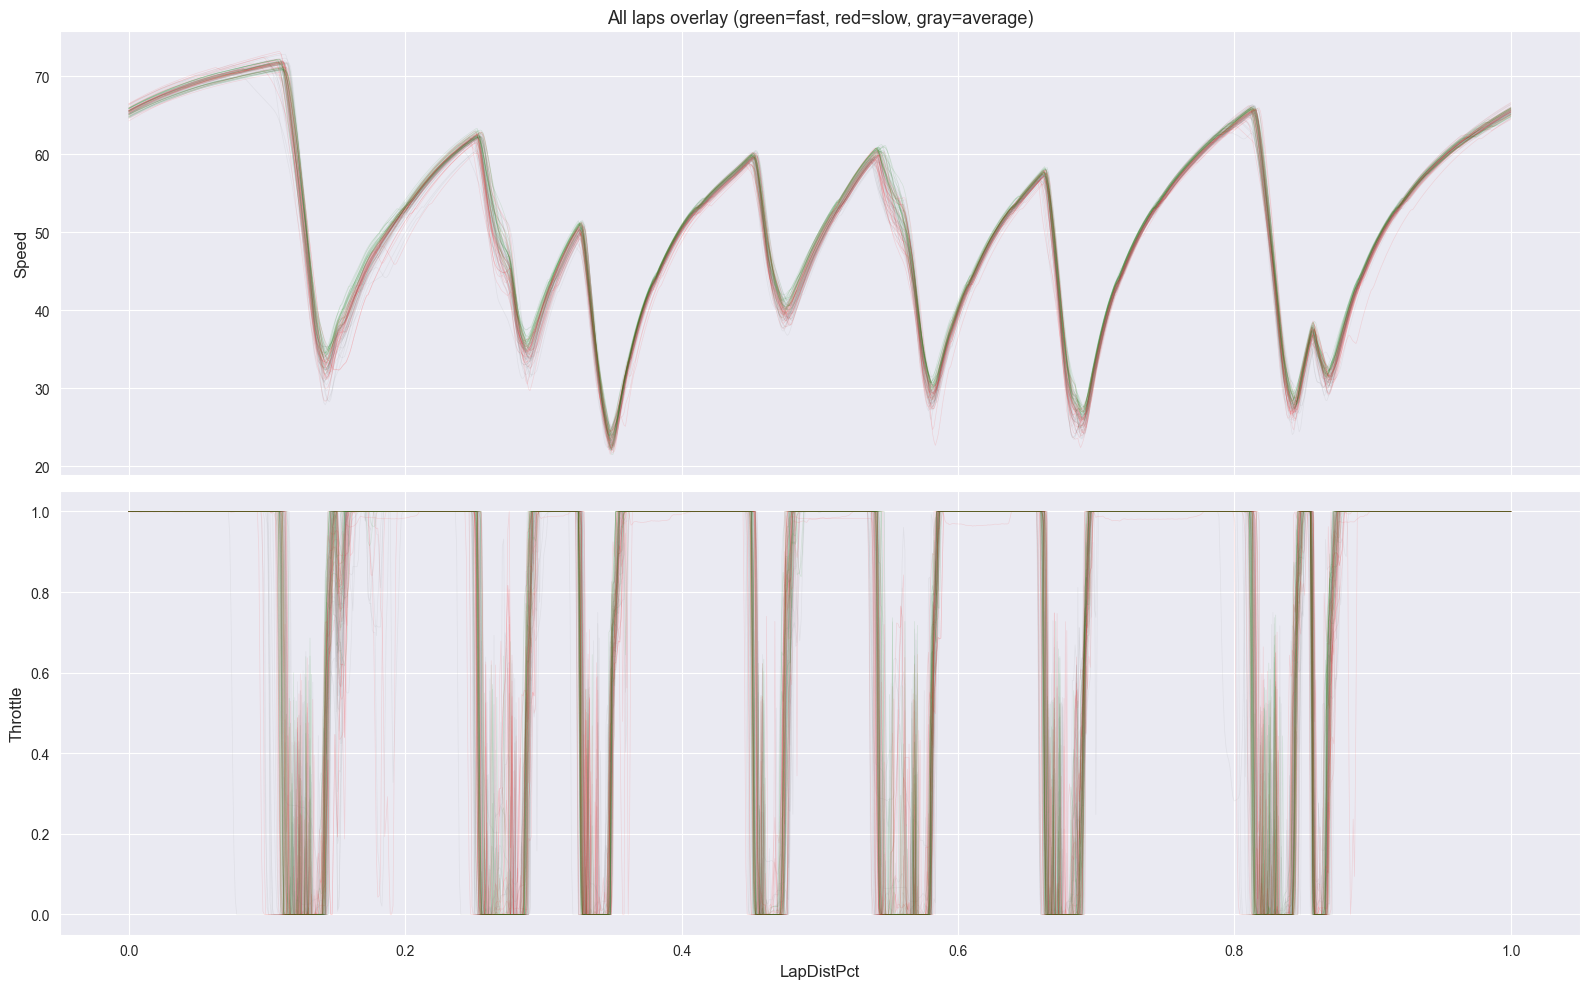

In [23]:
# Overlay ALL laps for Speed and Throttle
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

for lip in laps_interpolated:
    alpha = 0.1
    color = 'green' if lip['lap_time_s'].iloc[0] <= p25_thresh else ('red' if lip['lap_time_s'].iloc[0] >= p75_thresh else 'gray')
    axes[0].plot(lip['LapDistPct'], lip['Speed'], color=color, alpha=alpha, linewidth=0.5)
    axes[1].plot(lip['LapDistPct'], lip['Throttle'], color=color, alpha=alpha, linewidth=0.5)

axes[0].set_ylabel('Speed', fontsize=12)
axes[0].set_title('All laps overlay (green=fast, red=slow, gray=average)', fontsize=13)
axes[1].set_ylabel('Throttle', fontsize=12)
axes[1].set_xlabel('LapDistPct', fontsize=12)

plt.tight_layout()
plt.show()

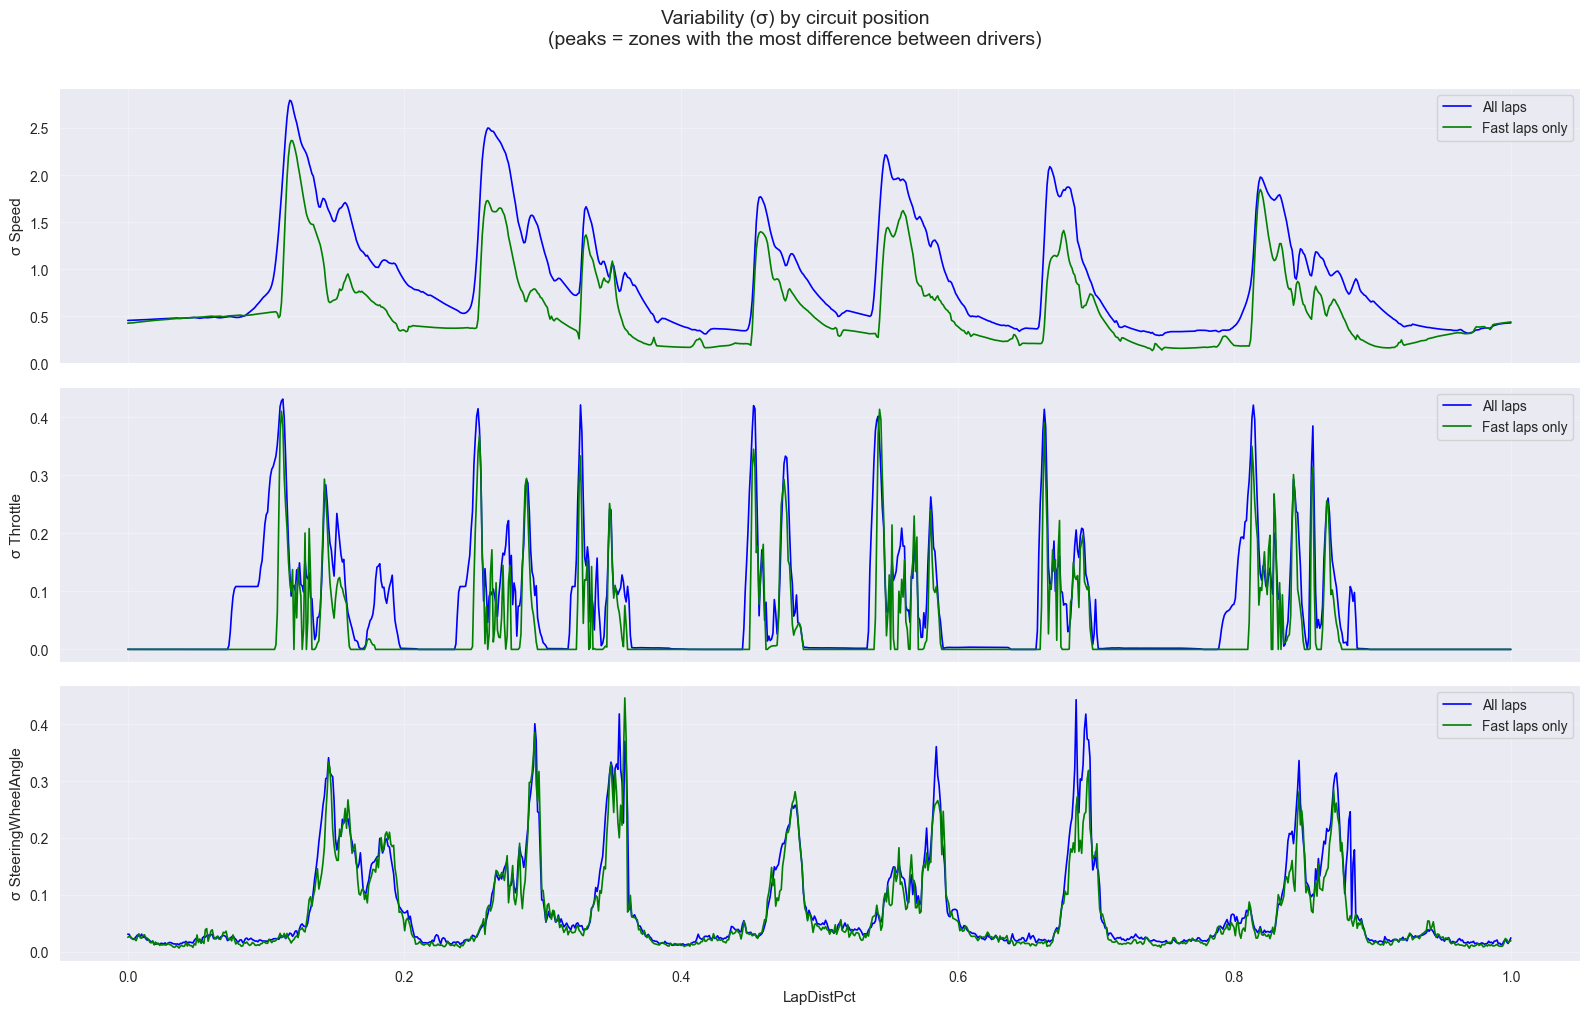

In [24]:
# Variability (standard deviation) along the lap for each channel
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

std_channels = ['Speed', 'Throttle', 'SteeringWheelAngle']
for i, ch in enumerate(std_channels):
    ch_idx = feature_cols.index(ch)
    all_std = telemetry_matrix[:, :, ch_idx].std(axis=0)
    fast_std = fast_matrix[:, :, ch_idx].std(axis=0)
    
    axes[i].plot(uniform_dist, all_std, 'b-', label='All laps', linewidth=1.2)
    axes[i].plot(uniform_dist, fast_std, 'g-', label='Fast laps only', linewidth=1.2)
    axes[i].set_ylabel(f'σ {ch}', fontsize=11)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('LapDistPct', fontsize=11)
fig.suptitle('Variability (σ) by circuit position\n(peaks = zones with the most difference between drivers)', 
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 12. G-G Diagram (Friction Circle)

The G-G diagram shows the combination of lateral and longitudinal acceleration. It is a classic tool for evaluating the use of available grip.

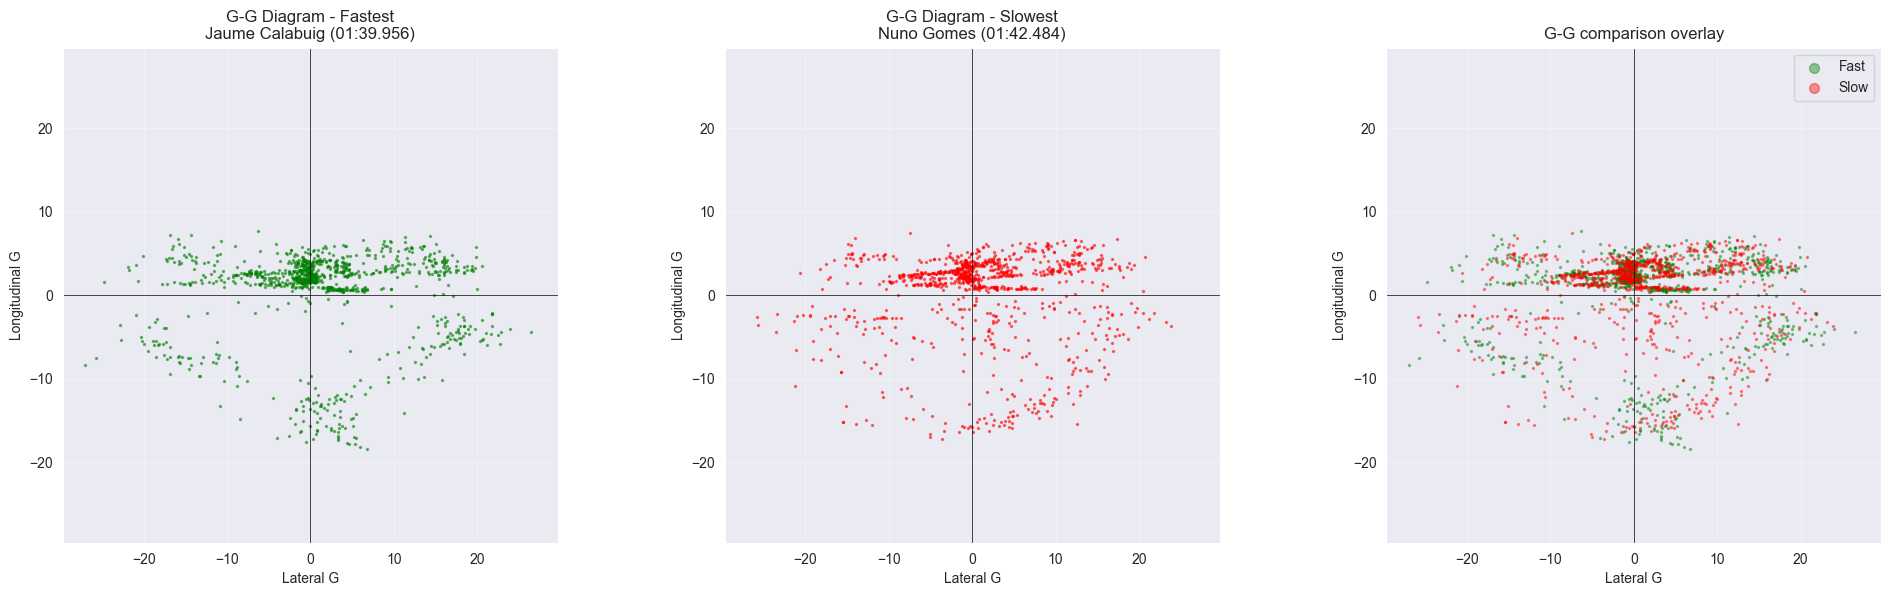

In [25]:
# G-G Diagram: fastest lap vs slowest lap
# Find the slowest lap
slowest_idx = meta_df['lap_time_s'].idxmax()
slowest_driver = meta_df.loc[slowest_idx, 'driver']
slowest_time = meta_df.loc[slowest_idx, 'lap_time_str']

for lip in laps_interpolated:
    if (lip['driver'].iloc[0] == slowest_driver and 
        abs(lip['lap_time_s'].iloc[0] - meta_df.loc[slowest_idx, 'lap_time_s']) < 0.001):
        slowest_interp = lip
        break

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Fastest lap
axes[0].scatter(fastest_interp['LatAccel'], fastest_interp['LongAccel'], s=2, alpha=0.5, c='green')
axes[0].set_xlabel('Lateral G')
axes[0].set_ylabel('Longitudinal G')
axes[0].set_title(f'G-G Diagram - Fastest\n{fastest_driver} ({fastest_time})')
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].axvline(0, color='black', linewidth=0.5)

# Slowest lap
axes[1].scatter(slowest_interp['LatAccel'], slowest_interp['LongAccel'], s=2, alpha=0.5, c='red')
axes[1].set_xlabel('Lateral G')
axes[1].set_ylabel('Longitudinal G')
axes[1].set_title(f'G-G Diagram - Slowest\n{slowest_driver} ({slowest_time})')
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].axvline(0, color='black', linewidth=0.5)

# Overlaid
axes[2].scatter(fastest_interp['LatAccel'], fastest_interp['LongAccel'], s=2, alpha=0.4, c='green', label='Fast')
axes[2].scatter(slowest_interp['LatAccel'], slowest_interp['LongAccel'], s=2, alpha=0.4, c='red', label='Slow')
axes[2].set_xlabel('Lateral G')
axes[2].set_ylabel('Longitudinal G')
axes[2].set_title('G-G comparison overlay')
axes[2].set_aspect('equal')
axes[2].grid(True, alpha=0.3)
axes[2].legend(markerscale=5)
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].axvline(0, color='black', linewidth=0.5)

# Match axes
all_lat = np.concatenate([fastest_interp['LatAccel'], slowest_interp['LatAccel']])
all_long = np.concatenate([fastest_interp['LongAccel'], slowest_interp['LongAccel']])
lim = max(np.abs(all_lat).max(), np.abs(all_long).max()) * 1.1
for ax in axes:
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

plt.tight_layout()
plt.show()

## 13. Exploration summary and model decisions

Recap key findings and decisions made for the next phases.

In [26]:
# Save interpolated data for the next phase
import os

output_dir = Path('../data/processed')
output_dir.mkdir(parents=True, exist_ok=True)

# Save telemetry matrix as numpy array
np.save(output_dir / 'imola_ferrari296_telemetry_matrix.npy', telemetry_matrix)
np.save(output_dir / 'imola_ferrari296_lap_times.npy', lap_times)
np.save(output_dir / 'imola_ferrari296_uniform_dist.npy', uniform_dist)

# Save metadata
meta_df.to_csv(output_dir / 'imola_ferrari296_metadata.csv', index=False)

# Save feature names
with open(output_dir / 'feature_cols.txt', 'w') as f:
    f.write('\n'.join(feature_cols))

print('=== DATA SAVED FOR PHASE 2 ===')
print(f'  📁 {output_dir}')
print(f'  📊 Telemetry matrix: {telemetry_matrix.shape}')
print(f'     → {telemetry_matrix.shape[0]} laps × {telemetry_matrix.shape[1]} points × {telemetry_matrix.shape[2]} features')
print(f'  🏁 Features: {feature_cols}')
print(f'  ⏱️  Lap times: {lap_times.shape}')
print(f'\n=== EXPLORATION SUMMARY ===')
print(f'  Total laps: {len(laps_data)}')
print(f'  Unique drivers: {meta_df["driver"].nunique()}')
print(f'  Time range: {meta_df["lap_time_s"].min():.3f}s - {meta_df["lap_time_s"].max():.3f}s (Δ = {meta_df["lap_time_s"].max() - meta_df["lap_time_s"].min():.3f}s)')
print(f'  Interpolated points per lap: {N_POINTS}')
print(f'  Selected features: {len(feature_cols)}')
print(f'\n=== DECISIONS FOR PHASE 2 (Model) ===')
print(f'  • Train Autoencoder-LSTM with the top {fast_mask.sum()} fast laps')
print(f'  • Input shape: ({N_POINTS}, {len(feature_cols)})')
print(f'  • Normalize per channel (Min-Max or Z-score)')
print(f'  • Evaluate reconstruction error on slow laps for validation')

=== DATA SAVED FOR PHASE 2 ===
  📁 ..\data\processed
  📊 Telemetry matrix: (84, 1000, 9)
     → 84 laps × 1000 points × 9 features
  🏁 Features: ['Speed', 'Throttle', 'Brake', 'RPM', 'SteeringWheelAngle', 'Gear', 'LatAccel', 'LongAccel', 'YawRate']
  ⏱️  Lap times: (84,)

=== EXPLORATION SUMMARY ===
  Total laps: 84
  Unique drivers: 54
  Time range: 99.956s - 102.484s (Δ = 2.528s)
  Interpolated points per lap: 1000
  Selected features: 9

=== DECISIONS FOR PHASE 2 (Model) ===
  • Train Autoencoder-LSTM with the top 21 fast laps
  • Input shape: (1000, 9)
  • Normalize per channel (Min-Max or Z-score)
  • Evaluate reconstruction error on slow laps for validation
